# Semestrální projekt 2

In [36]:
.libPaths("C:/Users/kulka/OneDrive/Skola/BI-PRS/package") 

#install.packages("eurostat")
#install.packages("ggplot2")
#install.packages("vtable")
#install.packages('cowplot')
#install.packages('psych')
#install.packages('dplyr')
#install.packages('DescTools')
#install.packages('MESS') # gkgamma
#install.packages("ggpubr") # ggdensity
library(ggpubr)

#install.packages("lmtest") # dwtest
library(lmtest)

#install.packages("tseries") # jarque.bera.test
library("tseries")

#install.packages("polycor") # biserial.cor
library("polycor")

#install.packages("ltm") # biserial.cor
library("ltm")

#install.packages("Sleuth2") # data
library(Sleuth2)

#install.packages("olsrr")
library(olsrr)

#install.packages("car")
library(car)

#install.packages("MASS")
library(MASS)

#install.packages("sfsmisc")
library(sfsmisc)

library(MESS)
library(DescTools)
library(dplyr)
library(psych)  
library(kableExtra)
library(moments)
library(cowplot)
library(eurostat)
library(ggplot2)
library(vtable)
library(corrplot)
library(e1071)

In [2]:
K = 11
L = 5 
((K+L)*47)%%(11)+1

[1] 5

## Popis dat

Budu pracovat s daty z "Proč mají někteří savci na svou velkost velký mozek?".

Databáze ma 96 pozorováni a 5 proměnných:
- Species
    - druh savce
    - 96 unikátních hodnot
    - řetězec znaku
- Brain
    - průměrná hmotnost mozku pro druh
    - číselná hodnota v gramech
    - vysvětlovaná proměnná
- Body
    - průměrná hmotnost druhu
    - číselná hodnota v kilogramech
- Gestation
    - průměrná doba březosti pro druh
    - číselná hodnota v dnech
- Litter
    - průměrná velikost vrhu
    - číselná hodnota

In [3]:
# upravím aby proměnné Brain a Body byly v stejných veličinách, gramy místo kilogramu
case0902$Body = case0902$Body * 1000

summ <- c('mean(x)', 'sd(x)', 'min(x)', 'pctile(x)[25]', 
          'median(x)', 'pctile(x)[75]', 'max(x)', 'IQR(x)',
          'skewness(x)', 'kurtosis(x)')

sumtable(case0902, out="return", summ=summ)

Variable,Mean,Sd,Min,Pctile[25],Median,Pctile[75],Max,IQR,Skewness,Kurtosis
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
Brain,219,507,0.45,13,74,260,4480,247,6.5,50
Body,108328,329411,17,2075,8900,94750,2800000,92675,6.4,46
Gestation,151,108,16,63,134,226,655,163,1.2,3.2
Litter,2.3,1.7,1,1,1.2,3.2,8,2.2,1.3,1.2


V datech se vyskytují různé druhy savců, od myší až po slony, tím pádem data mají velký rozsah. U Brain a Body je taky velký rozdíl mezi průměrem a mediánem a oba mají také vysokou šikmost a špičatost co implikuje ouliery. Gestation ma velký skok mezi horní hranici a maximem. Litter má nízkou šikmost a špičatost co by mohlo implikovat na normální rozdělení.

Graficky si data znázorním a podívám se bliž na outliery.

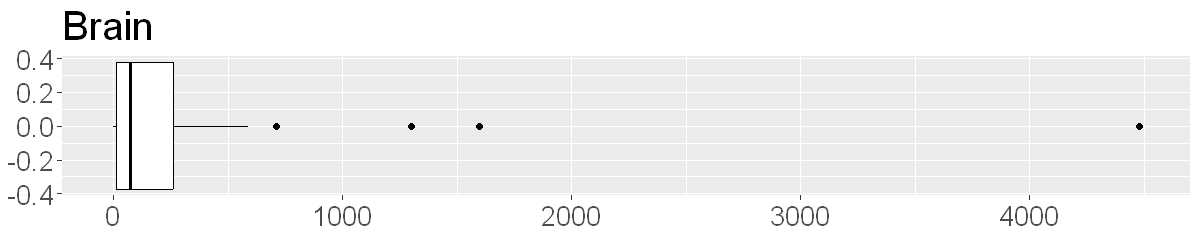

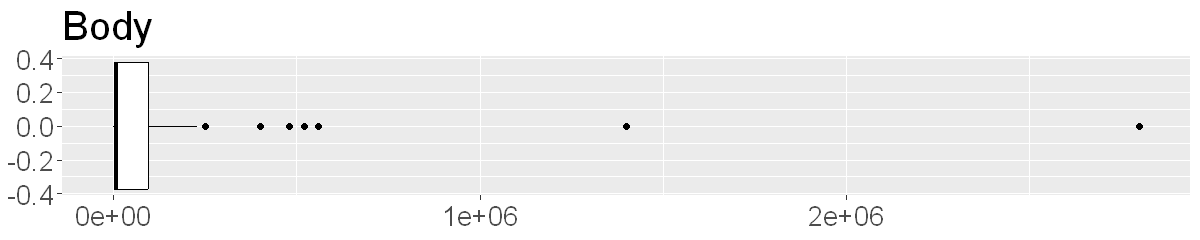

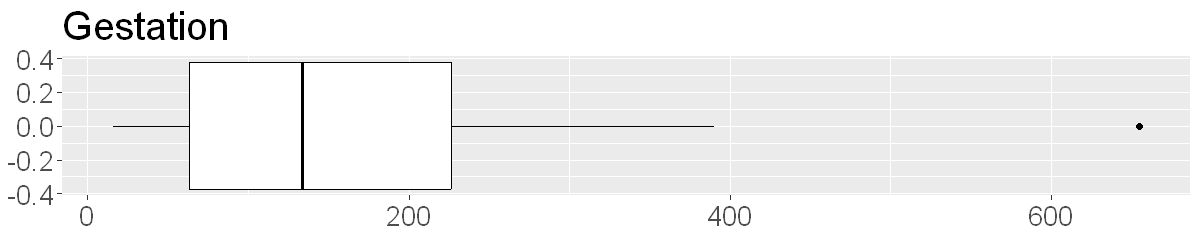

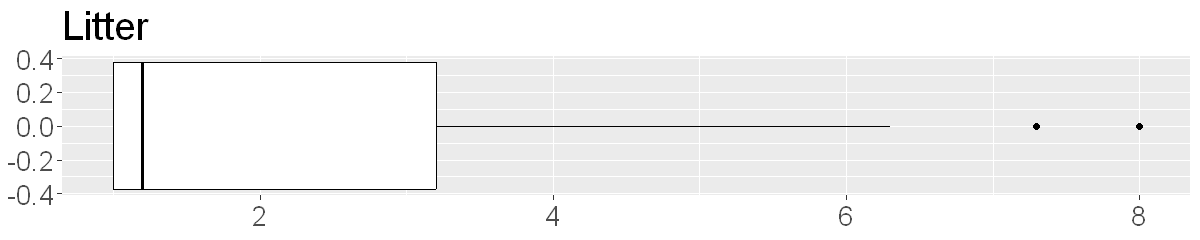

In [4]:
options(repr.plot.width = 10, repr.plot.height = 2)

ggplot(case0902, aes(x=Brain)) +
        ggtitle("Brain") +
        geom_boxplot(color="black", show.legend=F) +
        theme(axis.title = element_blank(), text = element_text(size = 20))
ggplot(case0902, aes(x=Body)) +
        ggtitle("Body") +
        geom_boxplot(color="black", show.legend=F) +
        theme(axis.title = element_blank(), text = element_text(size = 20))
ggplot(case0902, aes(x=Gestation)) +
        ggtitle("Gestation") +
        geom_boxplot(color="black", show.legend=F) +
        theme(axis.title = element_blank(), text = element_text(size = 20))
ggplot(case0902, aes(x=Litter)) +
        ggtitle("Litter") +
        geom_boxplot(color="black", show.legend=F) +
        theme(axis.title = element_blank(), text = element_text(size = 20))

In [5]:
Q3 <- quantile(case0902$Brain, .75)
IQR <- IQR(case0902$Brain)
outliers <- subset (case0902, case0902$Brain > (Q3 + 1.5*IQR))

Q3 <- quantile(case0902$Body, .75)
IQR <- IQR(case0902$Body)
outliers <- rbind (outliers, subset(case0902, case0902$Body > (Q3 + 1.5*IQR)))

Q3 <- quantile(case0902$Gestation, .75)
IQR <- IQR(case0902$Gestation)
outliers <- rbind (outliers, subset(case0902, case0902$Gestation > (Q3 + 1.5*IQR)))

Q3 <- quantile(case0902$Litter, .75)
IQR <- IQR(case0902$Litter)
outliers <- rbind (outliers, subset(case0902, case0902$Litter > (Q3 + 1.5*IQR)))

outliers_n = count(outliers, Species)
head(outliers_n[order(outliers_n$n, decreasing = TRUE), ], n = 3)

,Species,n
,<chr>,<int>
1,African elephant,3
10,Horse,2
2,Beaked whale,1


Africký slon se vyskytuje ve 3 outlierech (Brain, Body, Gestation) a kůň ve dvou (Brain, Body) u Litter to byly krysy a prase domácí.

Dál se podívam na korelaci.

,Brain,Body,Gestation,Litter
Brain,1.0000000,0.8640269,0.7281915,-0.2545611
Body,0.8640269,1.0000000,0.6246743,-0.1827372
Gestation,0.7281915,0.6246743,1.0000000,-0.6037515
Litter,-0.2545611,-0.1827372,-0.6037515,1.0000000


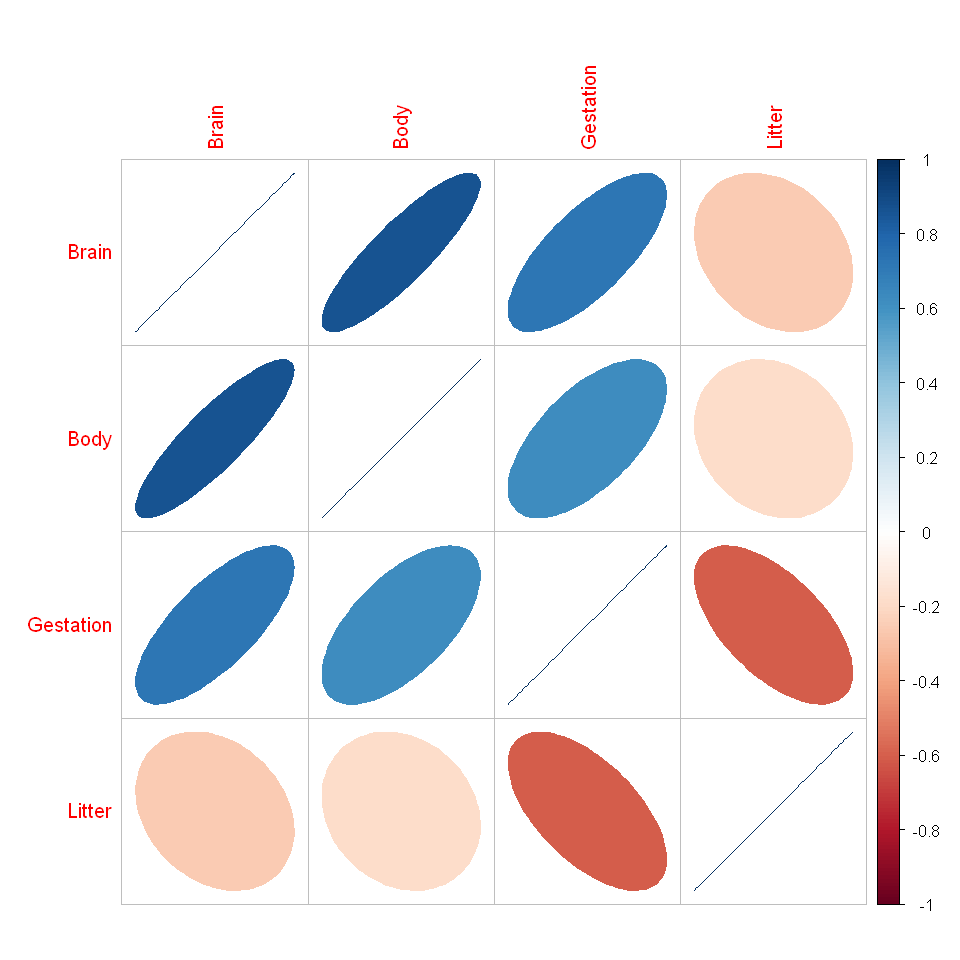

In [6]:
options(repr.plot.width = 8, repr.plot.height = 8)

cor_bbgl = cor(case0902[c('Brain', 'Body', 'Gestation', 'Litter')])
cor_bbgl
corrplot(cor_bbgl, method="ellipse")

Mám silnou pozitivní korelaci mezi Brain a Body, savci s větší tělesní vahou mají těžší mozek. <br>
Pozitivní korelaci mezi Gestation, Brain a Body, delší doba březosti implikuje vetší váhu mláděte a mozku. <br>
Vrh má negativní korelaci se všemi ostatními proměnnými.

Budu taky potřebovat jednu kategorickou proměnou ale v datasetu žádnou nemám taky si budu muset nějakou vytvořit. A taky se podívam na korelaci.

In [7]:
# vytvořil jsem si proměnou Diet podle potravy zvířete, ale ma slabé výsledky tak sem ji nakonec moc nevyužil
# ze zvědavosti se na ni alespoň trochu podívám
case0902$Diet = c('herbivore', 'omnivore', 'omnivore', 'omnivore', 'omnivore', 'omnivore', 'omnivore', 'omnivore', 'omnivore', 'omnivore',
                  'omnivore', 'omnivore', 'herbivore', 'omnivore', 'omnivore', 'omnivore', 'omnivore', 'omnivore', 'herbivore', 'omnivore',
                  'omnivore', 'omnivore', 'omnivore', 'omnivore', 'omnivore', 'omnivore', 'herbivore', 'omnivore', 'omnivore', 'herbivore',
                  'herbivore', 'omnivore', 'omnivore', 'omnivore', 'omnivore', 'omnivore', 'omnivore', 'omnivore', 'omnivore', 'omnivore',
                  'omnivore', 'omnivore', 'herbivore', 'herbivore', 'herbivore', 'omnivore', 'herbivore', 'omnivore', 'herbivore', 'omnivore',
                  'herbivore', 'carnivore', 'carnivore', 'omnivore', 'omnivore', 'omnivore', 'omnivore', 'omnivore', 'carnivore', 'omnivore',
                  'omnivore', 'omnivore', 'carnivore', 'carnivore', 'carnivore', 'carnivore', 'carnivore', 'carnivore', 'carnivore', 'carnivore',
                  'carnivore', 'herbivore', 'herbivore', 'herbivore', 'herbivore', 'omnivore', 'omnivore', 'herbivore', 'herbivore', 'herbivore', 
                  'herbivore', 'omnivore', 'herbivore', 'herbivore', 'herbivore', 'herbivore', 'herbivore', 'herbivore', 'herbivore', 'herbivore',
                  'herbivore', 'omnivore', 'herbivore', 'herbivore', 'herbivore', 'herbivore')

case0902$Litter = round(case0902$Litter)

case0902$Litter[case0902$Litter == 1] = 1                        # 1
case0902$Litter[case0902$Litter == 2 | case0902$Litter == 3] = 2 # 2, 3
case0902$Litter[case0902$Litter == 4 | case0902$Litter == 5] = 3 # 4, 5
case0902$Litter[case0902$Litter > 5] = 4                         # 6, 7, 8

case0902$Litter[case0902$Litter == 1] = "small"
case0902$Litter[case0902$Litter == 2] = "medium"
case0902$Litter[case0902$Litter == 3] = "large"
case0902$Litter[case0902$Litter == 4] = "very large"

Warning message:
"Removed 4 rows containing non-finite outside the scale range (`stat_boxplot()`)."
Warning message:
"Removed 4 rows containing non-finite outside the scale range (`stat_boxplot()`)."


,Df,Sum Sq,Mean Sq,F value,Pr(>F)
,<int>,<dbl>,<dbl>,<dbl>,<dbl>
Litter,3,2093210,697736.5,2.875542,0.04038201
Residuals,92,22323364,242645.3,NA,NA


,Df,Sum Sq,Mean Sq,F value,Pr(>F)
,<int>,<dbl>,<dbl>,<dbl>,<dbl>
Diet,2,1730850,865425.1,3.547805,0.03274598
Residuals,93,22685723,243932.5,NA,NA


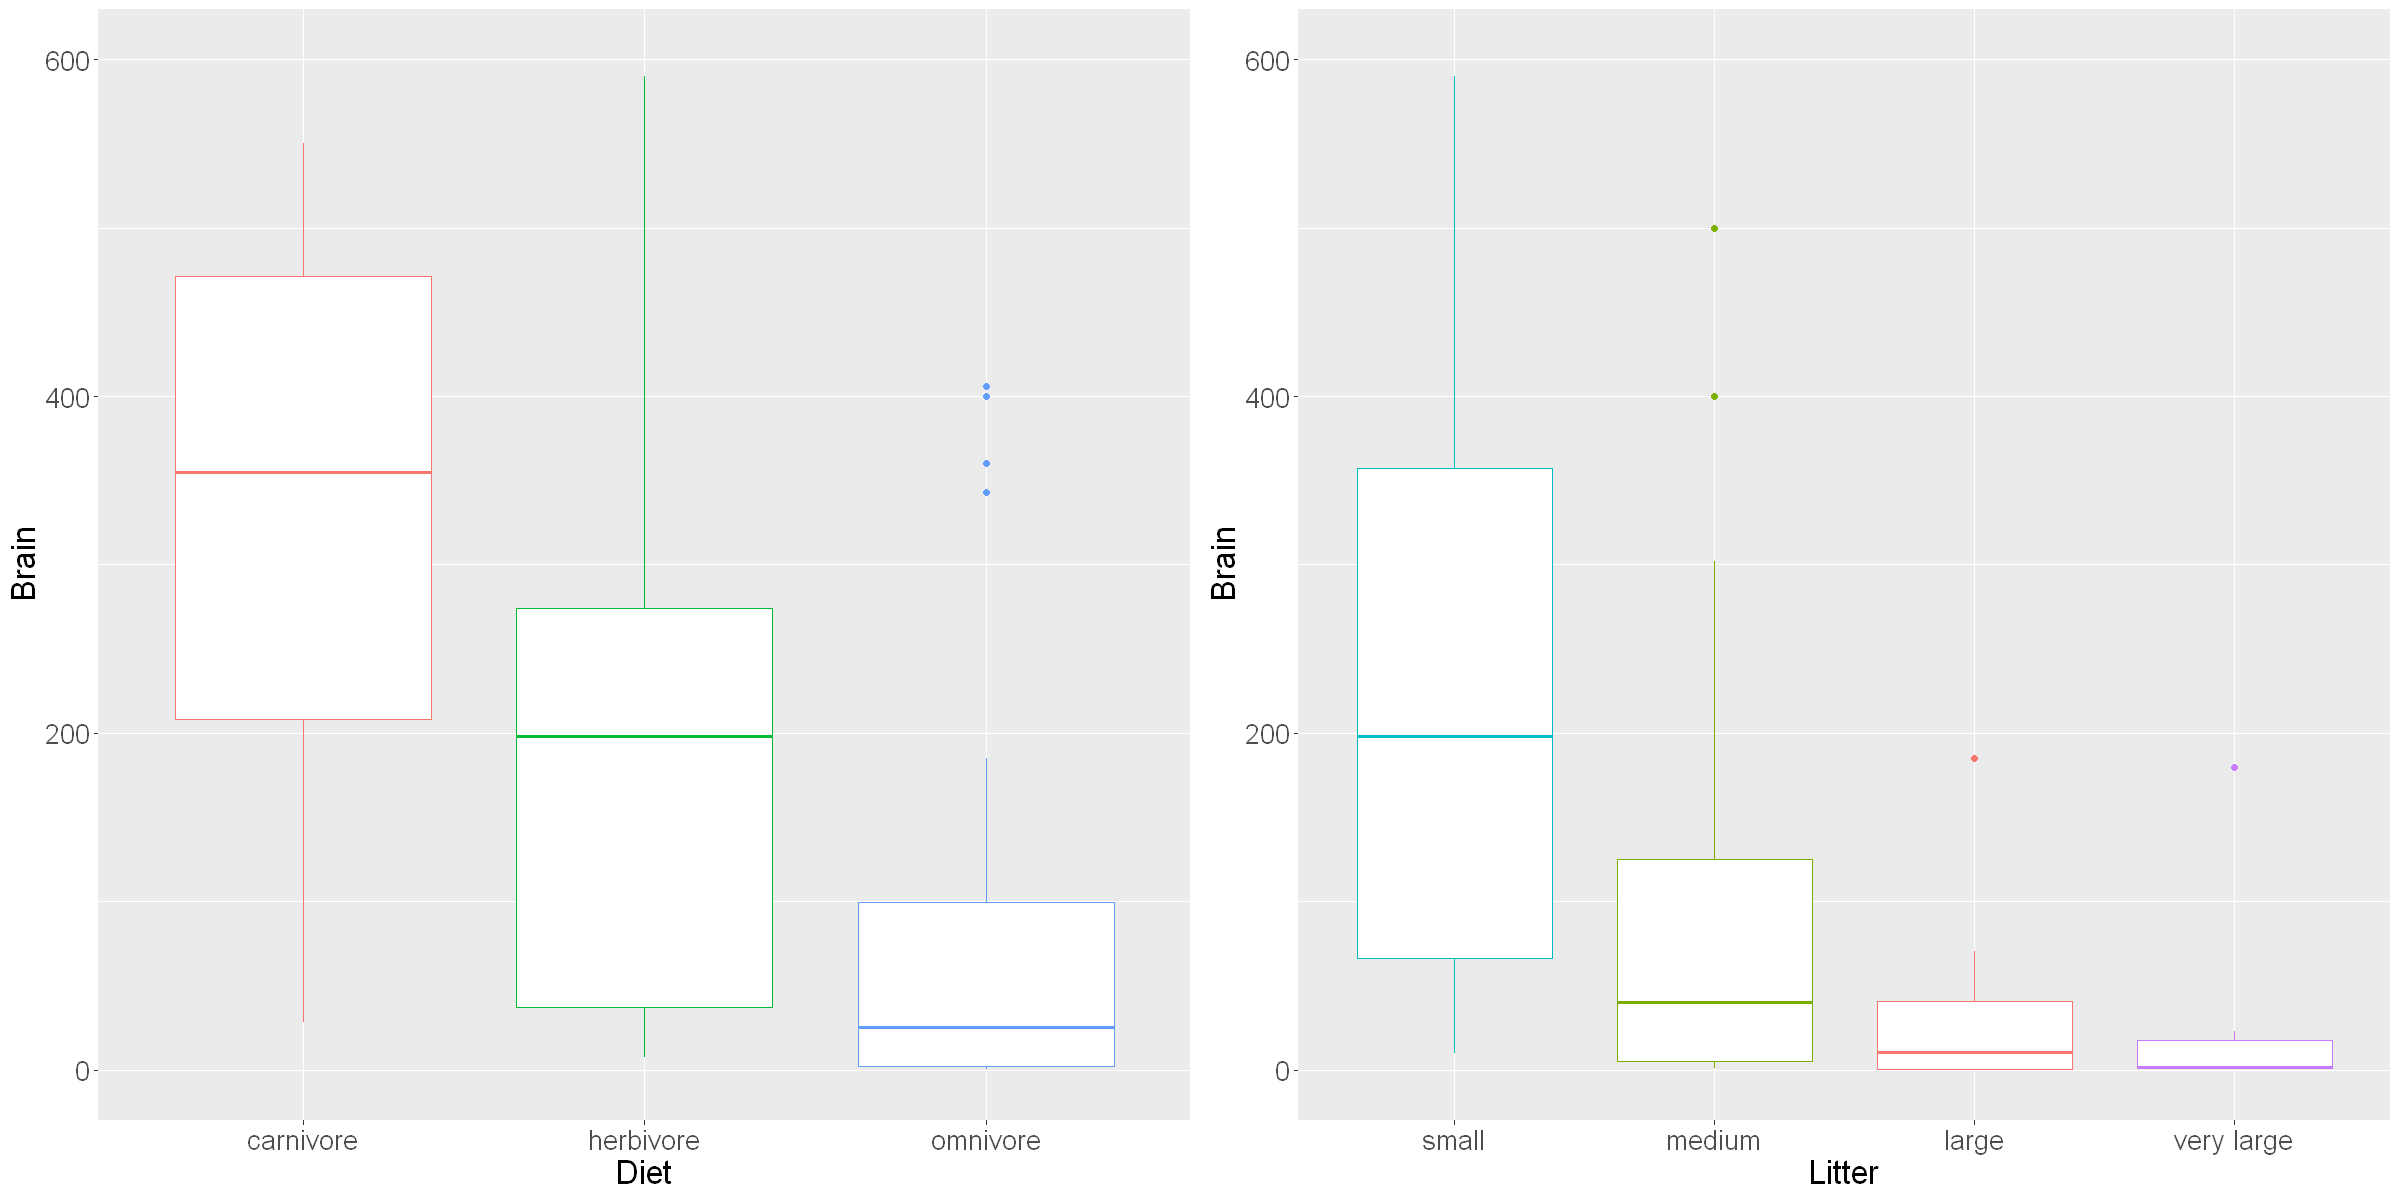

In [8]:
options(repr.plot.width = 20, repr.plot.height = 10)

g1 = ggplot(case0902, aes(x=Diet, y=Brain, color=Diet)) +
        geom_boxplot(show.legend=F) +
        theme(text = element_text(size = 20)) +
        scale_y_continuous(limits = c(0, 600)) # zmenším si rozsah abych lépe viděl hodnoty, i když ztratím pár outlieru

g2 = ggplot(case0902, aes(x=Litter, y=Brain, color=Litter)) +
        geom_boxplot(show.legend=F) +
        scale_x_discrete(limits = c("small", "medium", "large", "very large")) +
        theme(text = element_text(size = 20)) +
        scale_y_continuous(limits = c(0, 600))

plot_grid(g1, g2, nrow=1)

anova(aov(Brain ~ Litter, data = case0902))
anova(aov(Brain ~ Diet, data = case0902))

U obou promenných je významný rozdíl stedních hodnot a tudiž by měla existovat korelace, kterou je i videt na grafech. <br>
Zdroj potravy a váha mozku jsou nejspíš spojeny s obtížnosti jejího obstaráni. Masožravci musí vykonat největší úsilí zatím co všežravci nejméne.   
Čím vetší vrh tím menší váha mozku. Živiny se musí rozdělit mezi více mláďat, jednotlivě mládě tak dostane míň zdrojů na svůj vývoj. 

## Numerický regresor

Na vytvorení modelu použiji Body protože ma nejvetší korelaci. Podívam se taky na jeho varianty (lineárni, kvadratická, ...).

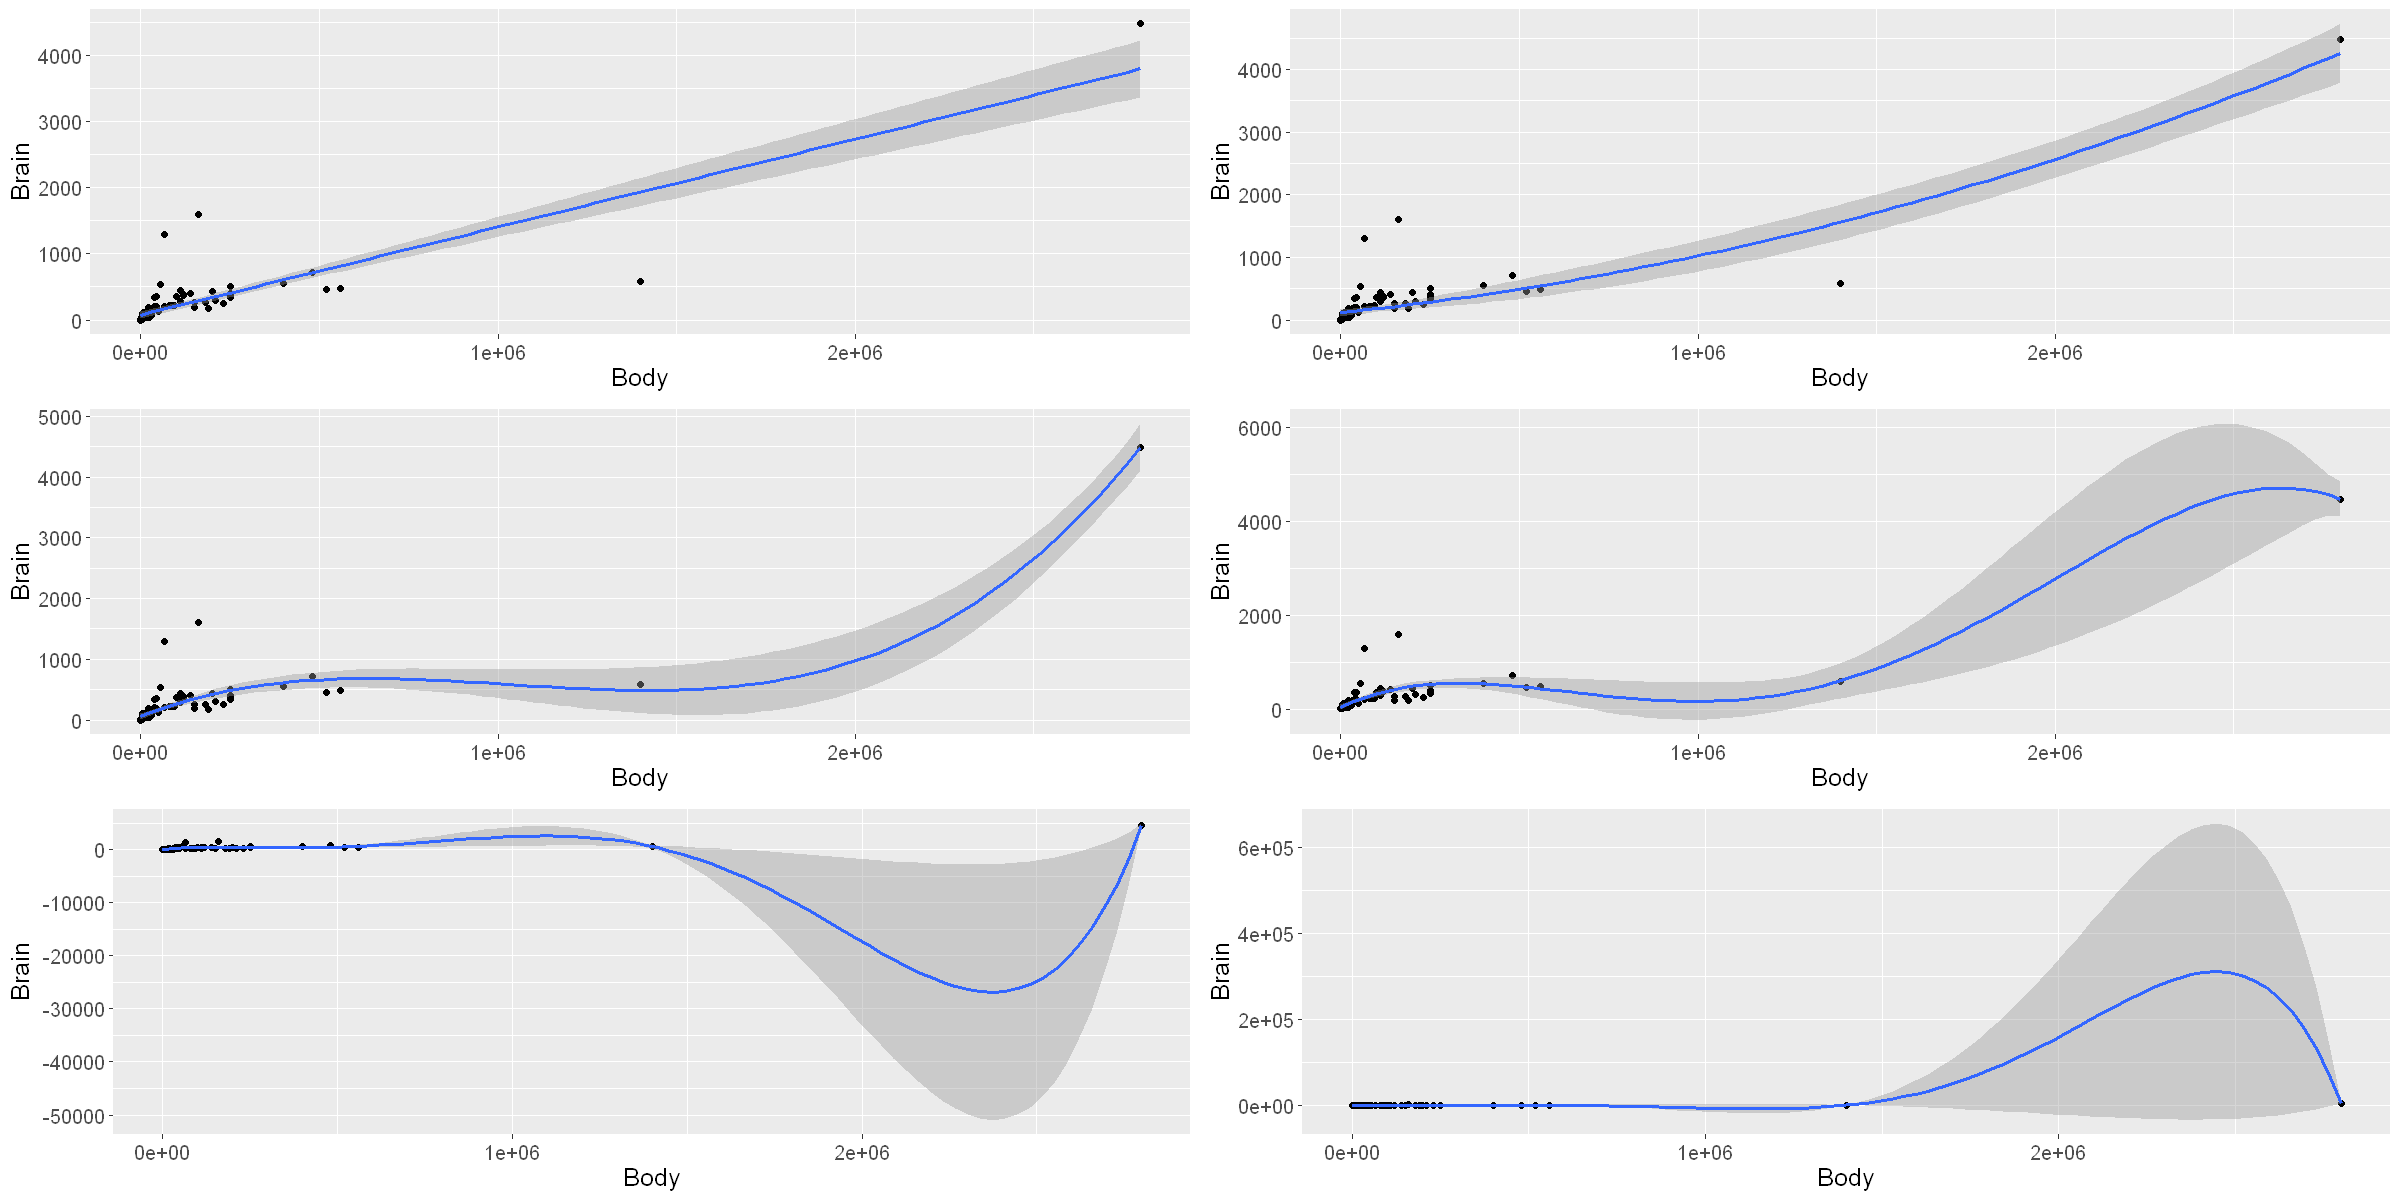

In [9]:
options(repr.plot.width = 20, repr.plot.height = 10)

g1 = ggplot(case0902, aes(x=Body, y=Brain)) +
         geom_point() +
         stat_smooth(method="lm", formula=y~x) +
         theme(text = element_text(size = 15))
g2 = ggplot(case0902, aes(x=Body, y=Brain)) +
         geom_point() +
         stat_smooth(method="lm", formula=y~x+I(x^2)) +
         theme(text = element_text(size = 15))
g3 = ggplot(case0902, aes(x=Body, y=Brain)) +
         geom_point() +
         stat_smooth(method="lm", formula=y~x+I(x^2)+I(x^3)) +
         theme(text = element_text(size = 15))
g4 = ggplot(case0902, aes(x=Body, y=Brain)) +
         geom_point() +
         stat_smooth(method="lm", formula=y~x+I(x^2)+I(x^3)+I(x^4)) +
         theme(text = element_text(size = 15))
g5 = ggplot(case0902, aes(x=Body, y=Brain)) +
         geom_point() +
         stat_smooth(method="lm", formula=y~x+I(x^2)+I(x^3)+I(x^4)+I(x^5)) +
         theme(text = element_text(size = 15))
g6 = ggplot(case0902, aes(x=Body, y=Brain)) +
         geom_point() +
         stat_smooth(method="lm", formula=y~x+I(x^2)+I(x^3)+I(x^4)+I(x^5)+I(x^6)) +
         theme(text = element_text(size = 15))

plot_grid(g1, g2, g3, g4, g5, g6, nrow=3)

In [10]:
caseBB = case0902[,1:3]

fitBB_one   = lm(Brain ~ Body, data = caseBB)
fitBB_two   = lm(Brain ~ Body + I(Body^2), data = caseBB)
fitBB_three = lm(Brain ~ Body + I(Body^2) + I(Body^3), data = caseBB)
fitBB_four  = lm(Brain ~ Body + I(Body^2) + I(Body^3) + I(Body^4), data = caseBB)
fitBB_five  = lm(Brain ~ Body + I(Body^2) + I(Body^3) + I(Body^4) + I(Body^5), data = caseBB)
fitBB_six   = lm(Brain ~ Body + I(Body^2) + I(Body^3) + I(Body^4) + I(Body^5) + I(Body^6), data = caseBB)

sumBB_one   = summary(fitBB_one)
sumBB_two   = summary(fitBB_two)
sumBB_three = summary(fitBB_three)
sumBB_four  = summary(fitBB_four)
sumBB_five  = summary(fitBB_five)
sumBB_six   = summary(fitBB_six)

print(paste("Residual standard error:", round(sumBB_one$sigma)))
print(paste("Multiple R-squared: ", round(sumBB_one$r.squared,4)))
print(paste("F-statistic: ", round(sumBB_one$fstatistic[1],1)))
print("-------------------------------------------------------")
print(paste("Residual standard error:", round(sumBB_two$sigma)))
print(paste("Multiple R-squared: ", round(sumBB_two$r.squared,4)))
print(paste("F-statistic: ", round(sumBB_two$fstatistic[1],1)))
print("-------------------------------------------------------")
print(paste("Residual standard error:", round(sumBB_three$sigma)))
print(paste("Multiple R-squared: ", round(sumBB_three$r.squared,4)))
print(paste("F-statistic: ", round(sumBB_three$fstatistic[1],1)))
print("-------------------------------------------------------")
print(paste("Residual standard error:", round(sumBB_four$sigma)))
print(paste("Multiple R-squared: ", round(sumBB_four$r.squared,4)))
print(paste("F-statistic: ", round(sumBB_four$fstatistic[1],1)))
print("-------------------------------------------------------")
print(paste("Residual standard error:", round(sumBB_five$sigma)))
print(paste("Multiple R-squared: ", round(sumBB_five$r.squared,4)))
print(paste("F-statistic: ", round(sumBB_five$fstatistic[1],1)))
print("-------------------------------------------------------")
print(paste("Residual standard error:", round(sumBB_six$sigma)))
print(paste("Multiple R-squared: ", round(sumBB_six$r.squared,4)))
print(paste("F-statistic: ", round(sumBB_six$fstatistic[1],1)))

[1] "Residual standard error: 257"
[1] "Multiple R-squared:  0.7465"
[1] "F-statistic:  276.9"
[1] "-------------------------------------------------------"
[1] "Residual standard error: 241"
[1] "Multiple R-squared:  0.7797"
[1] "F-statistic:  164.5"
[1] "-------------------------------------------------------"
[1] "Residual standard error: 194"
[1] "Multiple R-squared:  0.8582"
[1] "F-statistic:  185.5"
[1] "-------------------------------------------------------"
[1] "Residual standard error: 188"
[1] "Multiple R-squared:  0.8684"
[1] "F-statistic:  150.2"
[1] "-------------------------------------------------------"
[1] "Residual standard error: 182"
[1] "Multiple R-squared:  0.8774"
[1] "F-statistic:  128.8"
[1] "-------------------------------------------------------"
[1] "Residual standard error: 180"
[1] "Multiple R-squared:  0.8824"
[1] "F-statistic:  111.4"


Podle základních statistik se ze zvyšujícím stupněm polynomické rovnice zvyšuje přesnost modelu. Ze zvyšujícím se stupněm modelu se ale taky zvyšuje jeho komplexnost. Proto se podívám i na AIC a BIC.

In [11]:
fitbb_AIC = AIC(fitBB_one, fitBB_two, fitBB_three, fitBB_four, fitBB_five, fitBB_six)
fitbb_BIC = BIC(fitBB_one, fitBB_two, fitBB_three, fitBB_four, fitBB_five, fitBB_six)
fitbb_BIC$df = NULL
cbind( fitbb_AIC, fitbb_BIC )

,df,AIC,BIC
,<dbl>,<dbl>,<dbl>
fitBB_one,3,1341.527,1349.220
fitBB_two,4,1330.081,1340.338
fitBB_three,5,1289.806,1302.628
fitBB_four,6,1284.591,1299.977
fitBB_five,7,1279.793,1297.743
fitBB_six,8,1277.769,1298.284


Od šestého stupně se mi BIC začne znovu zvyšovat. U třetího stupně byl největší pokles AIC a BIC, to platilo i u předchozího pozorováni kde byl u třetího stupně největší narůst $R^2$. Se zvyšujícím se stupněm může být model ale přeučený, proto si radši vyberu model třetího stupně.

In [12]:
fitBB = fitBB_three
tmp = predict(fitBB, interval="prediction")
caseBB = cbind(caseBB, tmp)
head(caseBB)
summary(fitBB)

Warning message in predict.lm(fitBB, interval = "prediction"):
"predictions on current data refer to _future_ responses
"


,Species,Brain,Body,fit,lwr,upr
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,Quokka,17.50,3500,67.73808,-320.4695,455.9456
2,Hedgehog,3.50,930,61.91933,-326.3817,450.2203
3,Tree shrew,3.15,150,60.14663,-328.1840,448.4772
4,Elephant shrew I,1.14,49,59.91686,-328.4176,448.2513
5,Elephant shrew II,1.37,64,59.95099,-328.3829,448.2849
6,Lemur,22.00,2100,64.57253,-323.6852,452.8302



Call:
lm(formula = Brain ~ Body + I(Body^2) + I(Body^3), data = caseBB)

Residuals:
    Min      1Q  Median      3Q     Max 
-225.17  -58.81  -44.21   11.03 1238.43 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  5.981e+01  2.419e+01   2.473   0.0152 *  
Body         2.275e-03  2.922e-04   7.787 9.98e-12 ***
I(Body^2)   -2.567e-09  4.101e-10  -6.258 1.22e-08 ***
I(Body^3)    8.282e-16  1.161e-16   7.134 2.18e-10 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 194 on 92 degrees of freedom
Multiple R-squared:  0.8582,	Adjusted R-squared:  0.8535 
F-statistic: 185.5 on 3 and 92 DF,  p-value: < 2.2e-16


Vzorec pro odhad váhy mozgu podle telesní hmotnosti pro model je:
$$Brain = 59.805 + 2.275e^{-3} \cdot Body - 2.567e^{-9} \cdot Body^2 + 8.282e^{-16} \cdot Body^3$$

Všechny koeficienty (${\beta}_0$, $Body$, $Body^2$, $Body^3$) mají statisticky významný vliv na proměnou Brain. Zbytková standardní chyba je 194, v průměru se pozorované hodnoty odchylují od fittovaných přibližně o 194 gramů. Hodnota $R^2$ ukazuje, že přibližně 85,82 % rozptylu Brain je vysvětleno Body, regresor takže by měl dobre vysvetlovat regresand. Hodnoty Multiple $R^2$ a Adjusted $R^2$ jsou si podobné co taky poukazuje na dobrou kvalitu modelu. F-statistika s p-hodnotou mi ukazuje, že model je statisticky významný. 

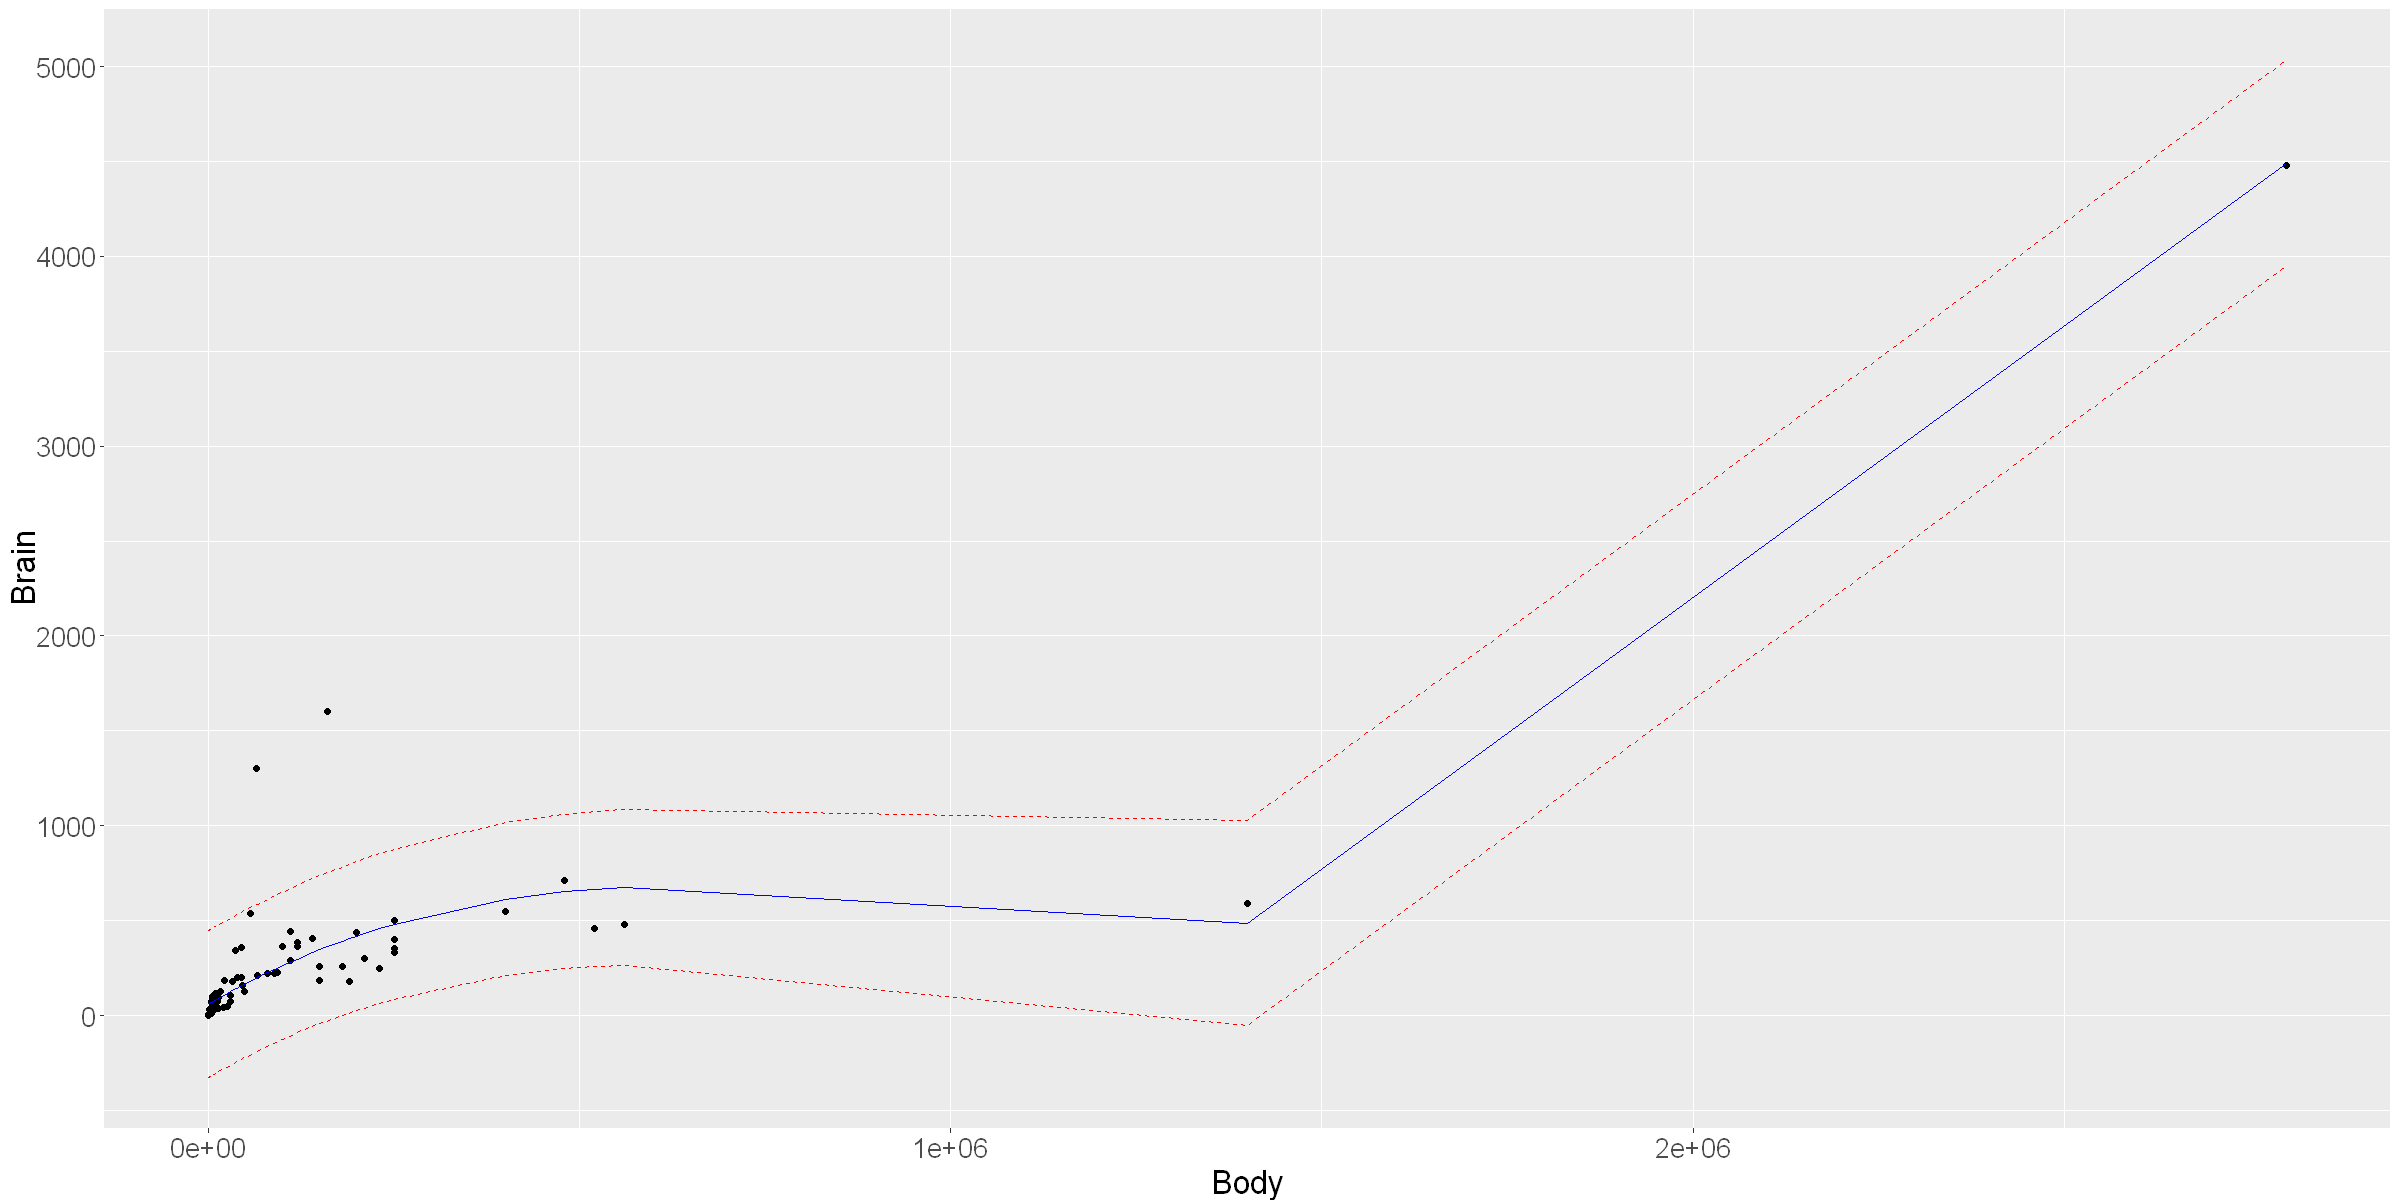

In [13]:
ggplot(caseBB, aes(x=Body, y=Brain)) +
    geom_point() +
    geom_line(aes(y=fit), color="blue") +
    geom_line(aes(y=lwr), color = "red", linetype = "dashed") +
    geom_line(aes(y=upr), color = "red", linetype = "dashed") +
        theme(text = element_text(size = 20))

,Species,Brain,Body,fit,lwr,upr
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
24,Human being,1300,65000,197.0938,-190.4623,584.6498
52,Dolphin,1600,160000,361.5655,-28.9461,752.0771
53,Porpoise,537,56000,179.3277,-208.1582,566.8136


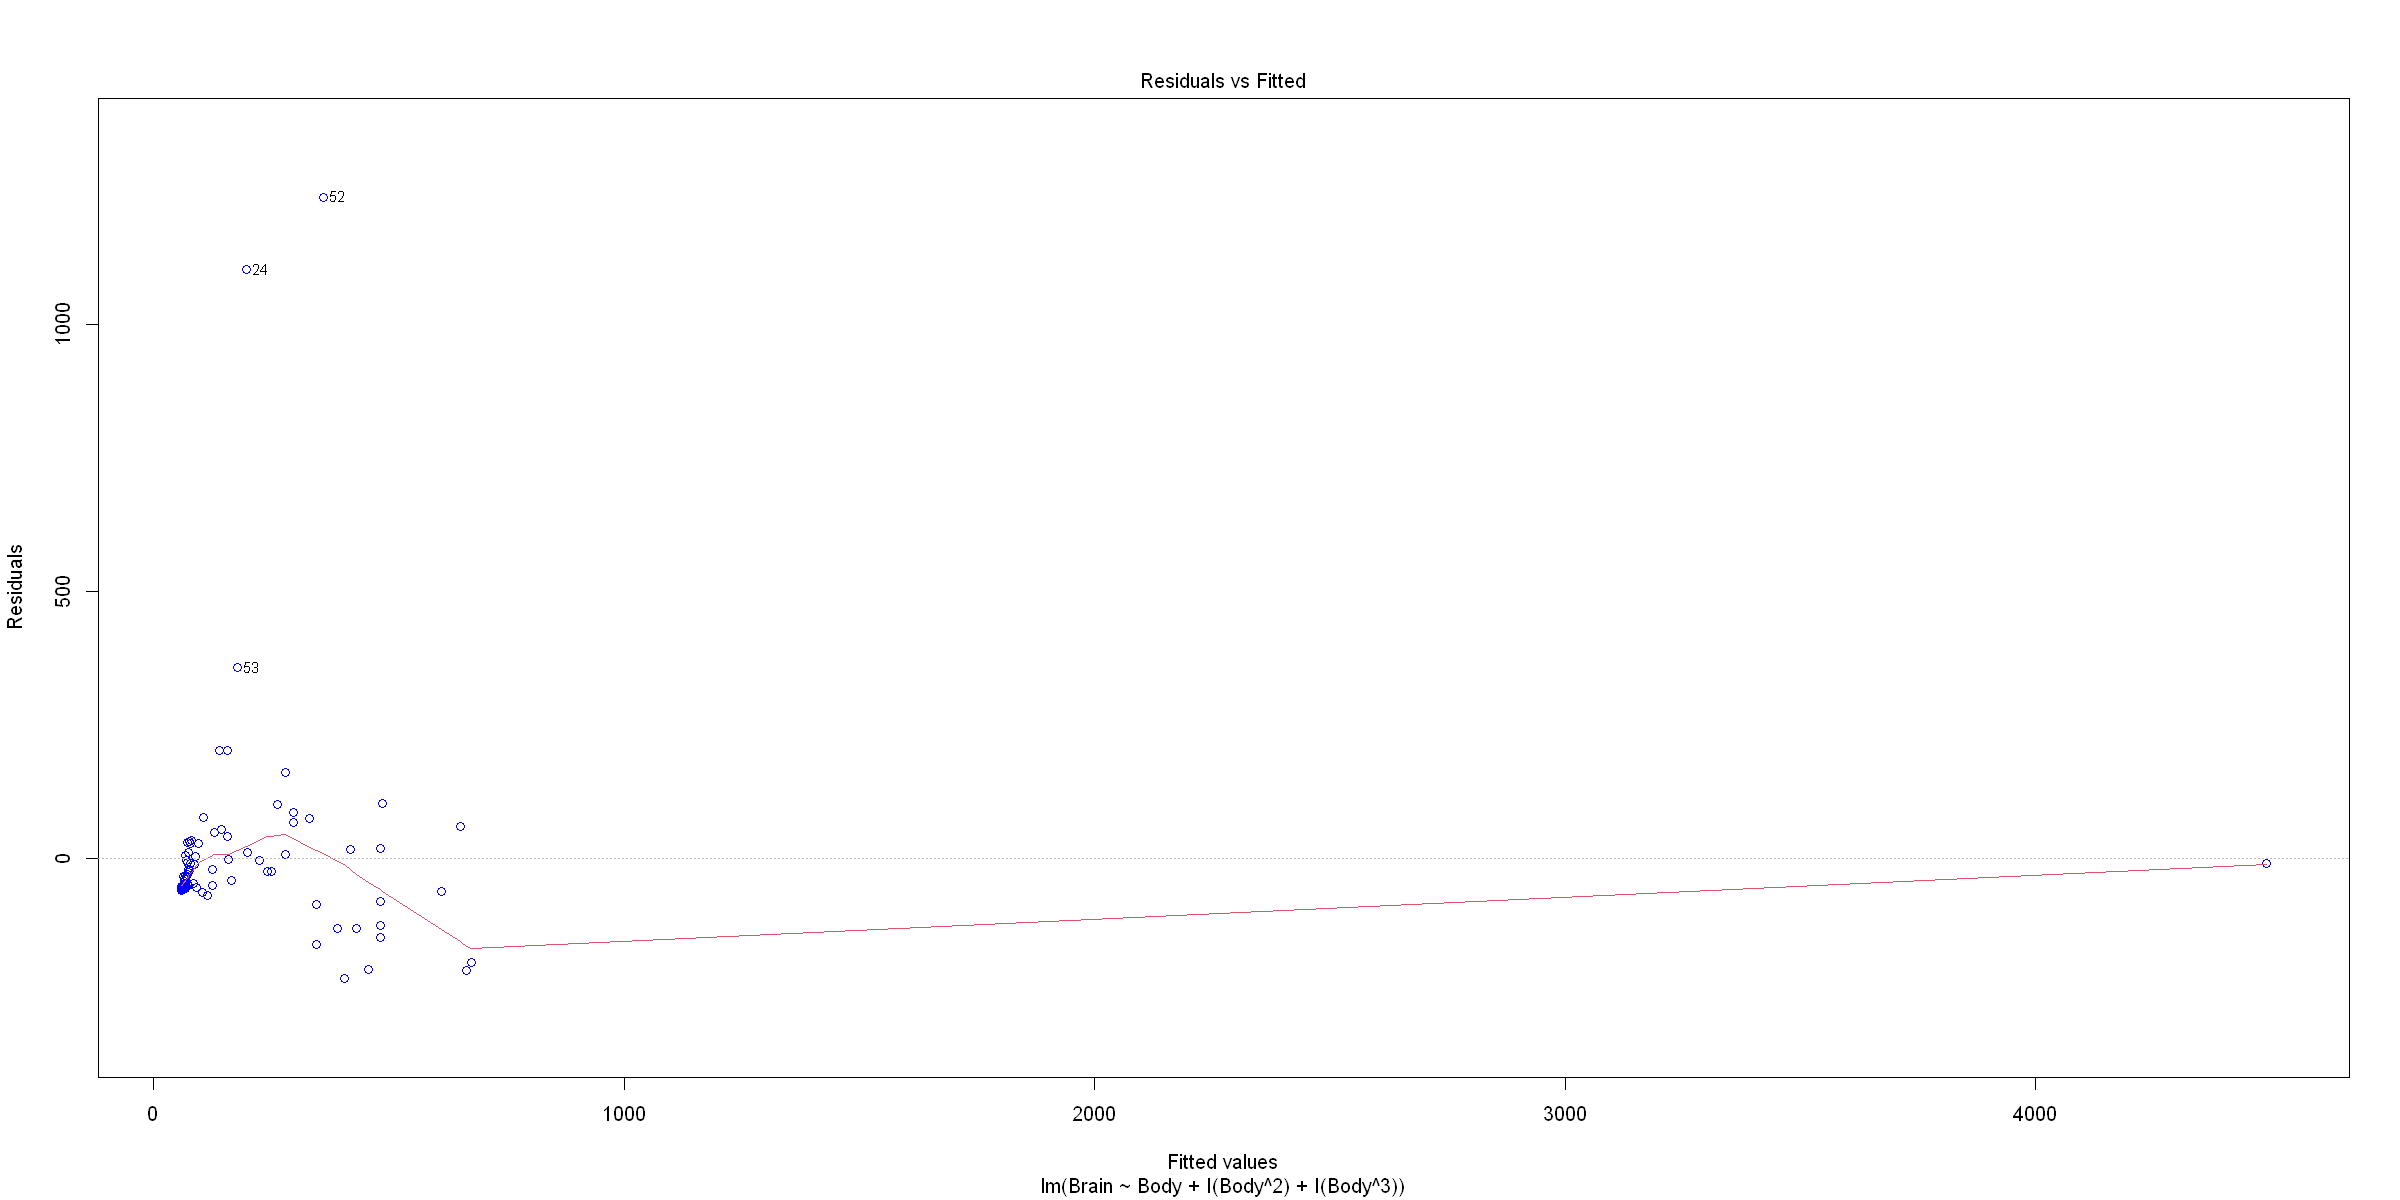

In [14]:
plot(fitBB, which=1, col=c("blue"))
caseBB[c(24,52,53),]

Model má celkem dobrý odhad až na několik velkých outlierů, ale v datech jsou taky velké outliery tak se to tady asi odzrcadlilo. Zvyšováním stupně polynomické regrese se graf reziduí zlepší ale outliery tam zůstanou.

## Kategorický regresor

Jako kategorický regresor si zvolím proměnnou vrh.

In [15]:
caseBL = case0902[,c(1,2,5)]

fitBL = lm(Brain ~ Litter, data = caseBL)
tmp = predict(fitBL, interval="prediction")
caseBL = cbind(caseBL, tmp)
head(caseBL)
summary(fitBL)

Warning message in predict.lm(fitBL, interval = "prediction"):
"predictions on current data refer to _future_ responses
"


,Species,Brain,Litter,fit,lwr,upr
,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
1,Quokka,17.50,small,355.70000,-632.1718,1343.572
2,Hedgehog,3.50,large,28.54333,-976.5921,1033.679
3,Tree shrew,3.15,medium,102.80524,-898.5443,1104.155
4,Elephant shrew I,1.14,medium,102.80524,-898.5443,1104.155
5,Elephant shrew II,1.37,medium,102.80524,-898.5443,1104.155
6,Lemur,22.00,small,355.70000,-632.1718,1343.572



Call:
lm(formula = Brain ~ Litter, data = caseBL)

Residuals:
   Min     1Q Median     3Q    Max 
-345.8 -156.2  -30.2   13.9 4124.3 

Coefficients:
                 Estimate Std. Error t value Pr(>|t|)  
(Intercept)         28.54     116.11   0.246   0.8064  
Littermedium        74.26     158.22   0.469   0.6399  
Littersmall        327.16     135.05   2.423   0.0174 *
Littervery large     6.19     232.21   0.027   0.9788  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 492.6 on 92 degrees of freedom
Multiple R-squared:  0.08573,	Adjusted R-squared:  0.05592 
F-statistic: 2.876 on 3 and 92 DF,  p-value: 0.04038


Odhad váhy mozgu podle vrhu: 

$$
\texttt{Brain} = 
\begin{cases}
\beta_0 + {\beta_2} &\text{pokud }\texttt{Litter == small}, \\
\beta_0 + {\beta_1} &\text{pokud }\texttt{Litter == medium}, \\
\beta_0 & \text{pokud } \texttt{Litter == large}, \\
\beta_0 + {\beta_3} &\text{pokud }\texttt{Litter == very large}
\end{cases}
$$

Přepsáno, průměrná váha mozků u velkého vrhu (4 až 5 mláďat) je 28.54 gramu. <br>
U malého vrhu (1 mládě) je průměr váhy mozků vetší o 327.16 gramu než u velkého vrhu, celkem tedy 355.70 gramu. <br>
U středního vrhu (2 až 3 mláďata) je průměr váhy mozků vetší o 74.26 gramu než u velkého vrhu, celkem tedy 102.80 gramu. <br>
A u velmi velkého vrhu (víc než 6 mláďat) je průměr váhy mozků vetší o 6.19 gramu než u velkého vrhu, celkem tedy 34.73 gramu. <br>

Jenom jeden koeficient (${\beta}_2$) má statistický významy vliv na odhad váhy mozku. I když p-hodnota je menší než 0.05 a tím pádem model má statistický vliv, nízká hodnota F-statistiky, $R^2$ a vysoka reziduální standardní chyba poukazuje na to, že vrh odhaduje jen malou část rozsahu vahy mozku (8.57 %) a není moc dobrým modelem. <br>

Udelám analýzu rozptylu.

In [16]:
TukeyHSD(aov(Brain ~ Litter, data = caseBL))

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = Brain ~ Litter, data = caseBL)

$Litter
                       diff        lwr      upr     p adj
medium-large        74.2619 -339.74935 488.2732 0.9655940
small-large        327.1567  -26.21274 680.5261 0.0799180
very large-large     6.1900 -601.41241 613.7924 0.9999931
small-medium       252.8948  -81.29816 587.0877 0.2030158
very large-medium  -68.0719 -664.72562 528.5818 0.9906921
very large-small  -320.9667 -877.25821 235.3249 0.4359017


Ani jeden rozdíl není statistický významný. Takže neexistuje žádný významný rozdíl mezi průměrem velikosti mozku a různými skupinami vrhu. A tudíž nemůžu dojít k závěru, že váha mozku se výrazně liší v závislosti na vrhu.

Warning message:
"Removed 4 rows containing non-finite outside the scale range (`stat_boxplot()`)."


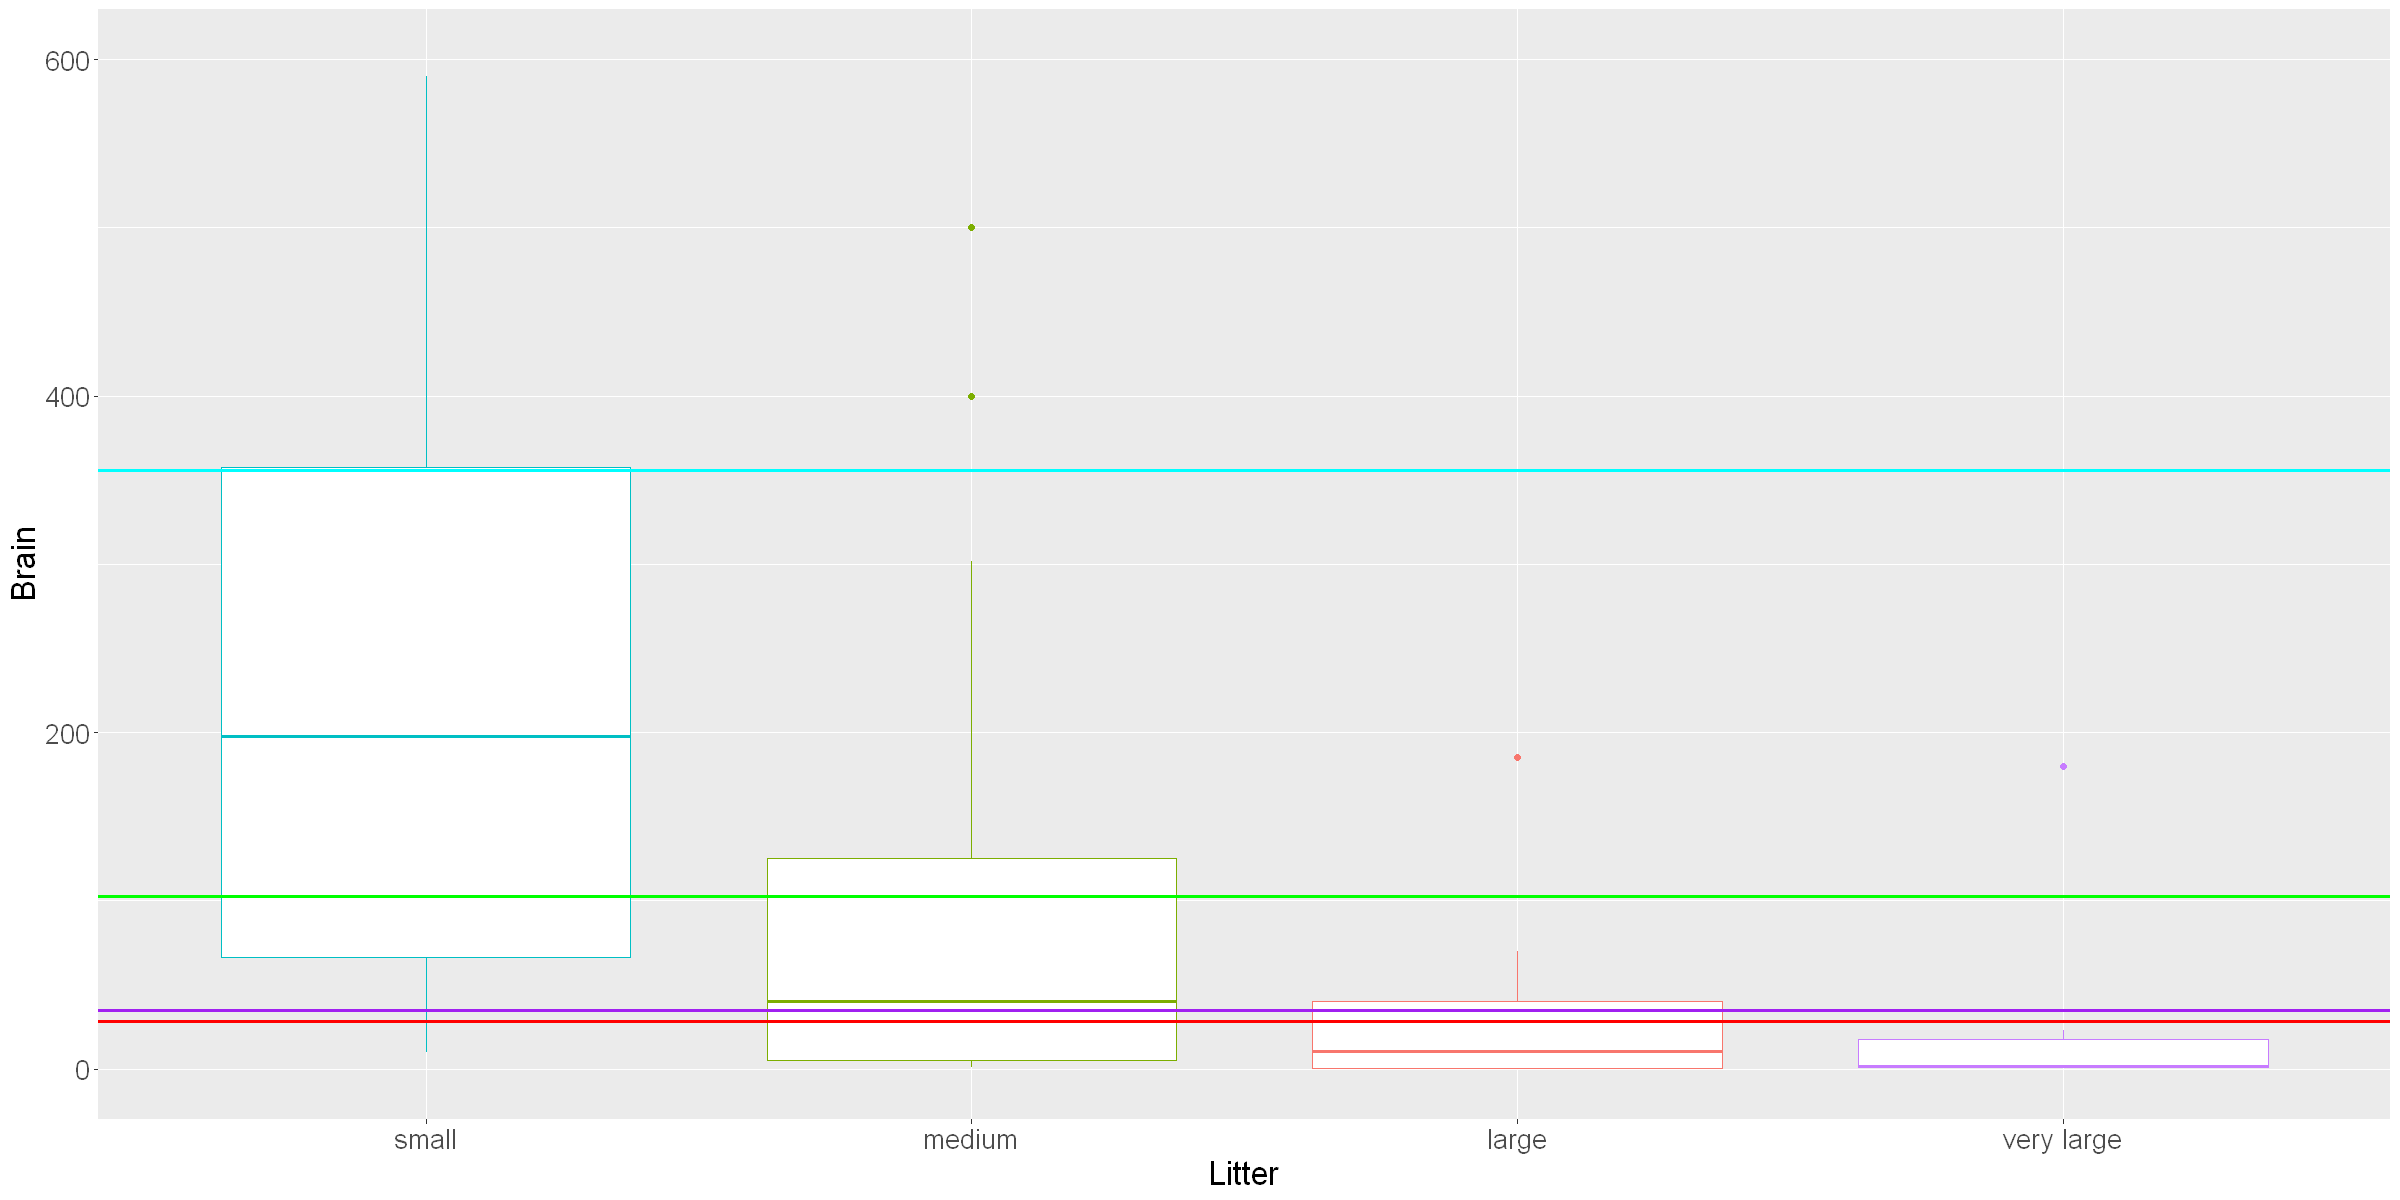

In [17]:
ggplot(caseBL, aes(x=Litter, y=Brain, color=Litter)) +
        geom_boxplot(show.legend=F) +
        geom_hline(yintercept = fitBL$coef[1] + fitBL$coef[3], color = "cyan", linewidth = 1.1) +
        geom_hline(yintercept = fitBL$coef[1] + fitBL$coef[2], color = "green", linewidth = 1.1) +
        geom_hline(yintercept = fitBL$coef[1]                , color = "red", linewidth = 1.1) +
        geom_hline(yintercept = fitBL$coef[1] + fitBL$coef[4], color = "purple", linewidth = 1.1) +
        scale_x_discrete(limits = c("small", "medium", "large", "very large")) +
        theme(text = element_text(size = 20)) + # vykreslení je ořezáno
        scale_y_continuous(limits = c(0, 600))

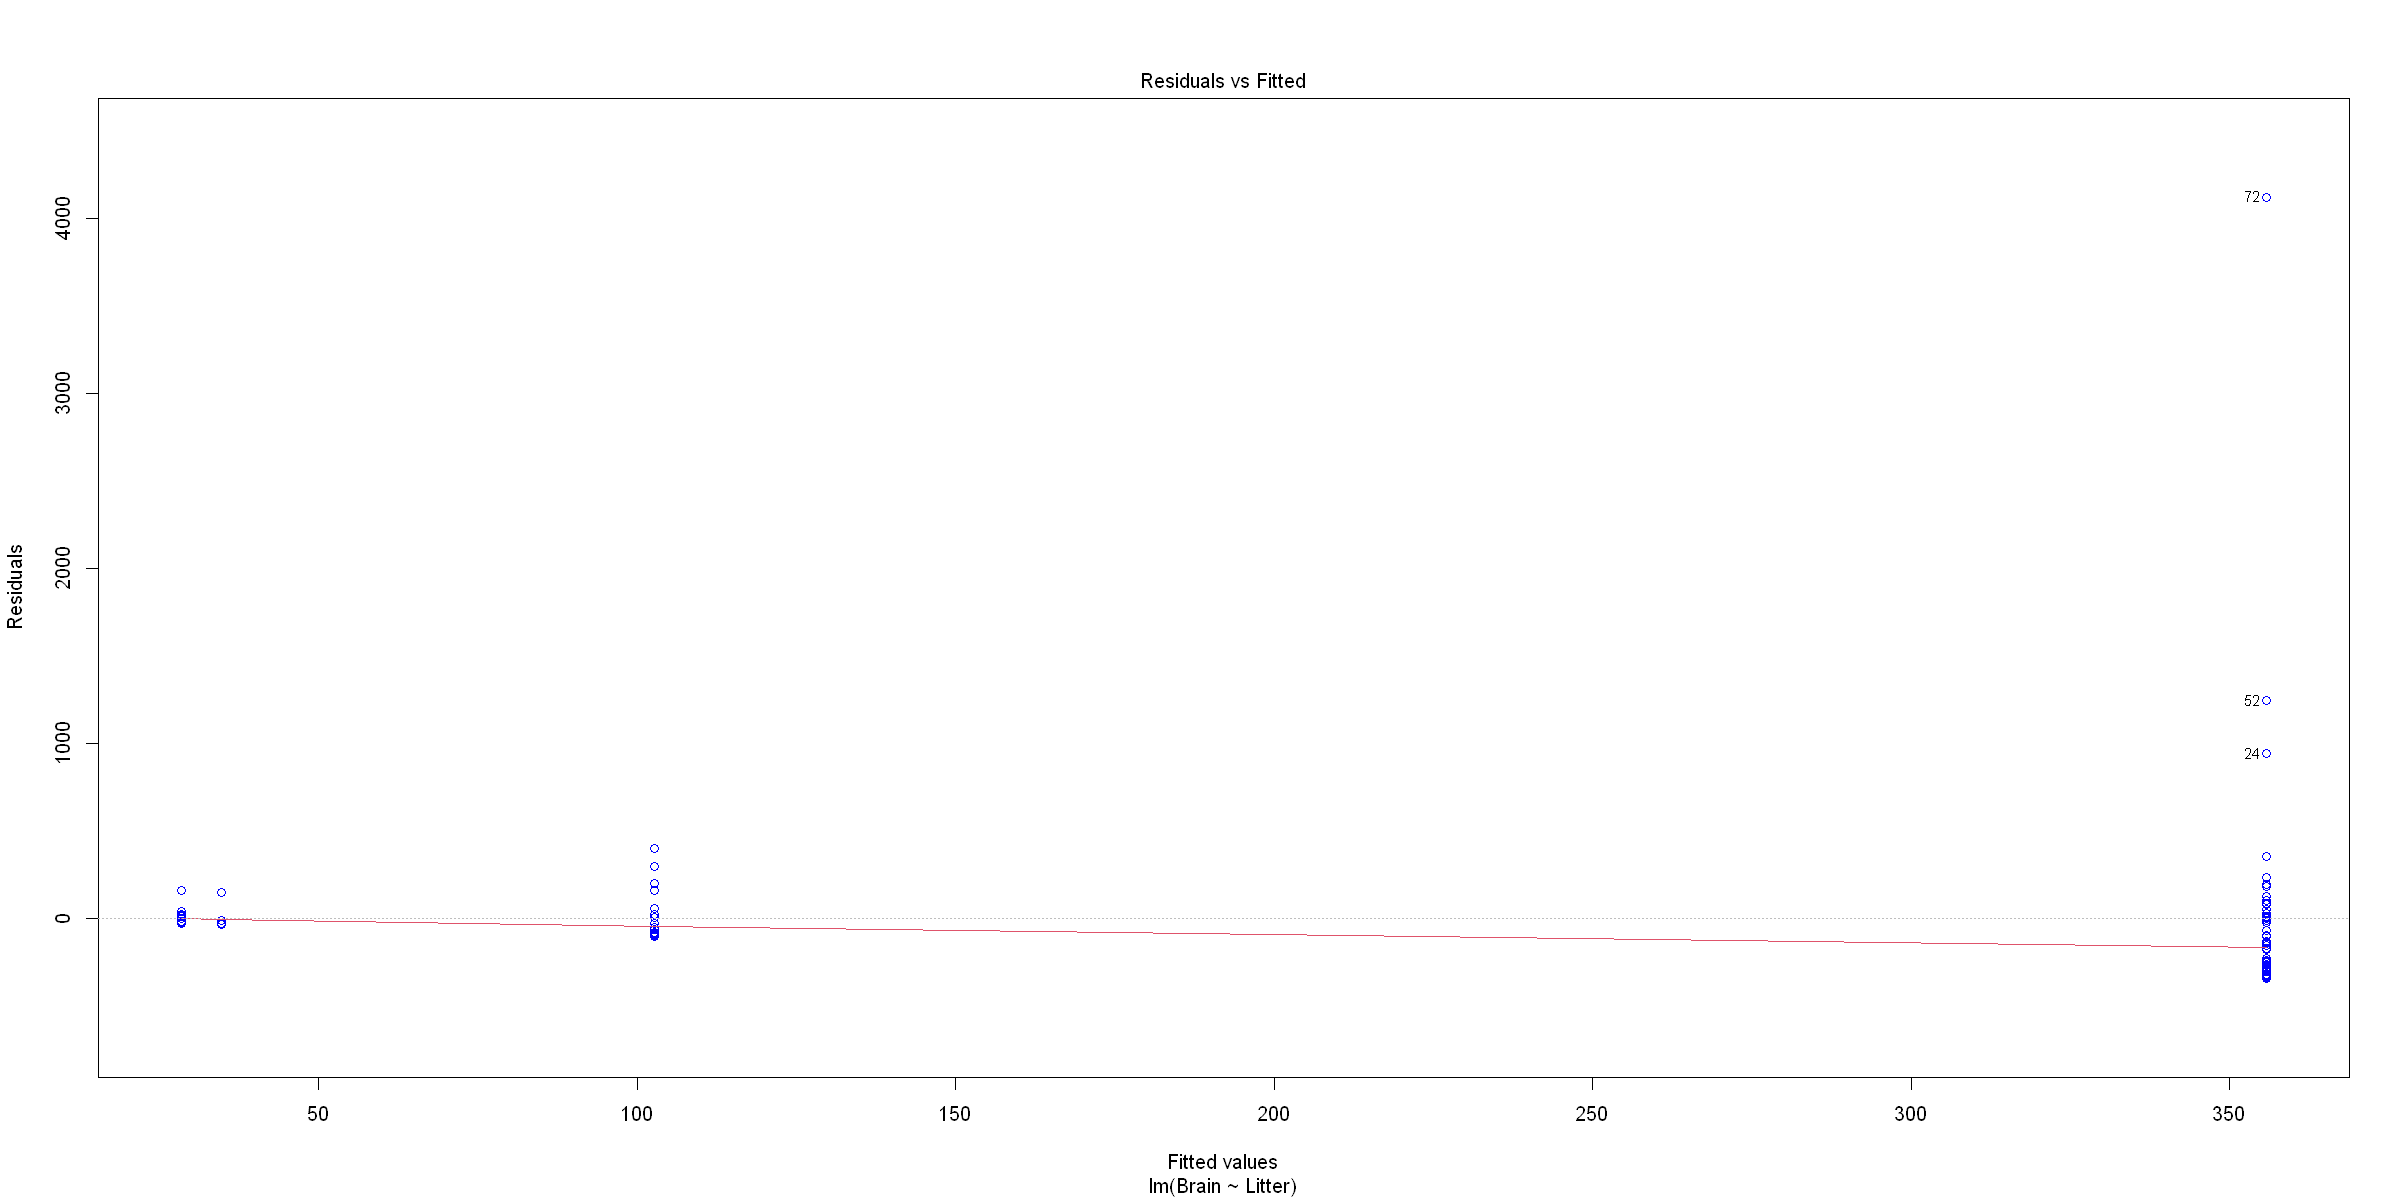

In [18]:
plot(fitBL, which=1, col=c("blue"))

Model odhaduje jenom 4 hodnoty, nemůže tak pokryt velkou část rozsahu a není dobrým modelem.

## Dva regresory

Ťed vytvorím model odhadujíci váhu mozků pomocí hmotnosti a vrhu.

Warning message:
"Removed 6 rows containing non-finite outside the scale range (`stat_smooth()`)."
Warning message:
"Removed 6 rows containing missing values or values outside the scale range (`geom_point()`)."


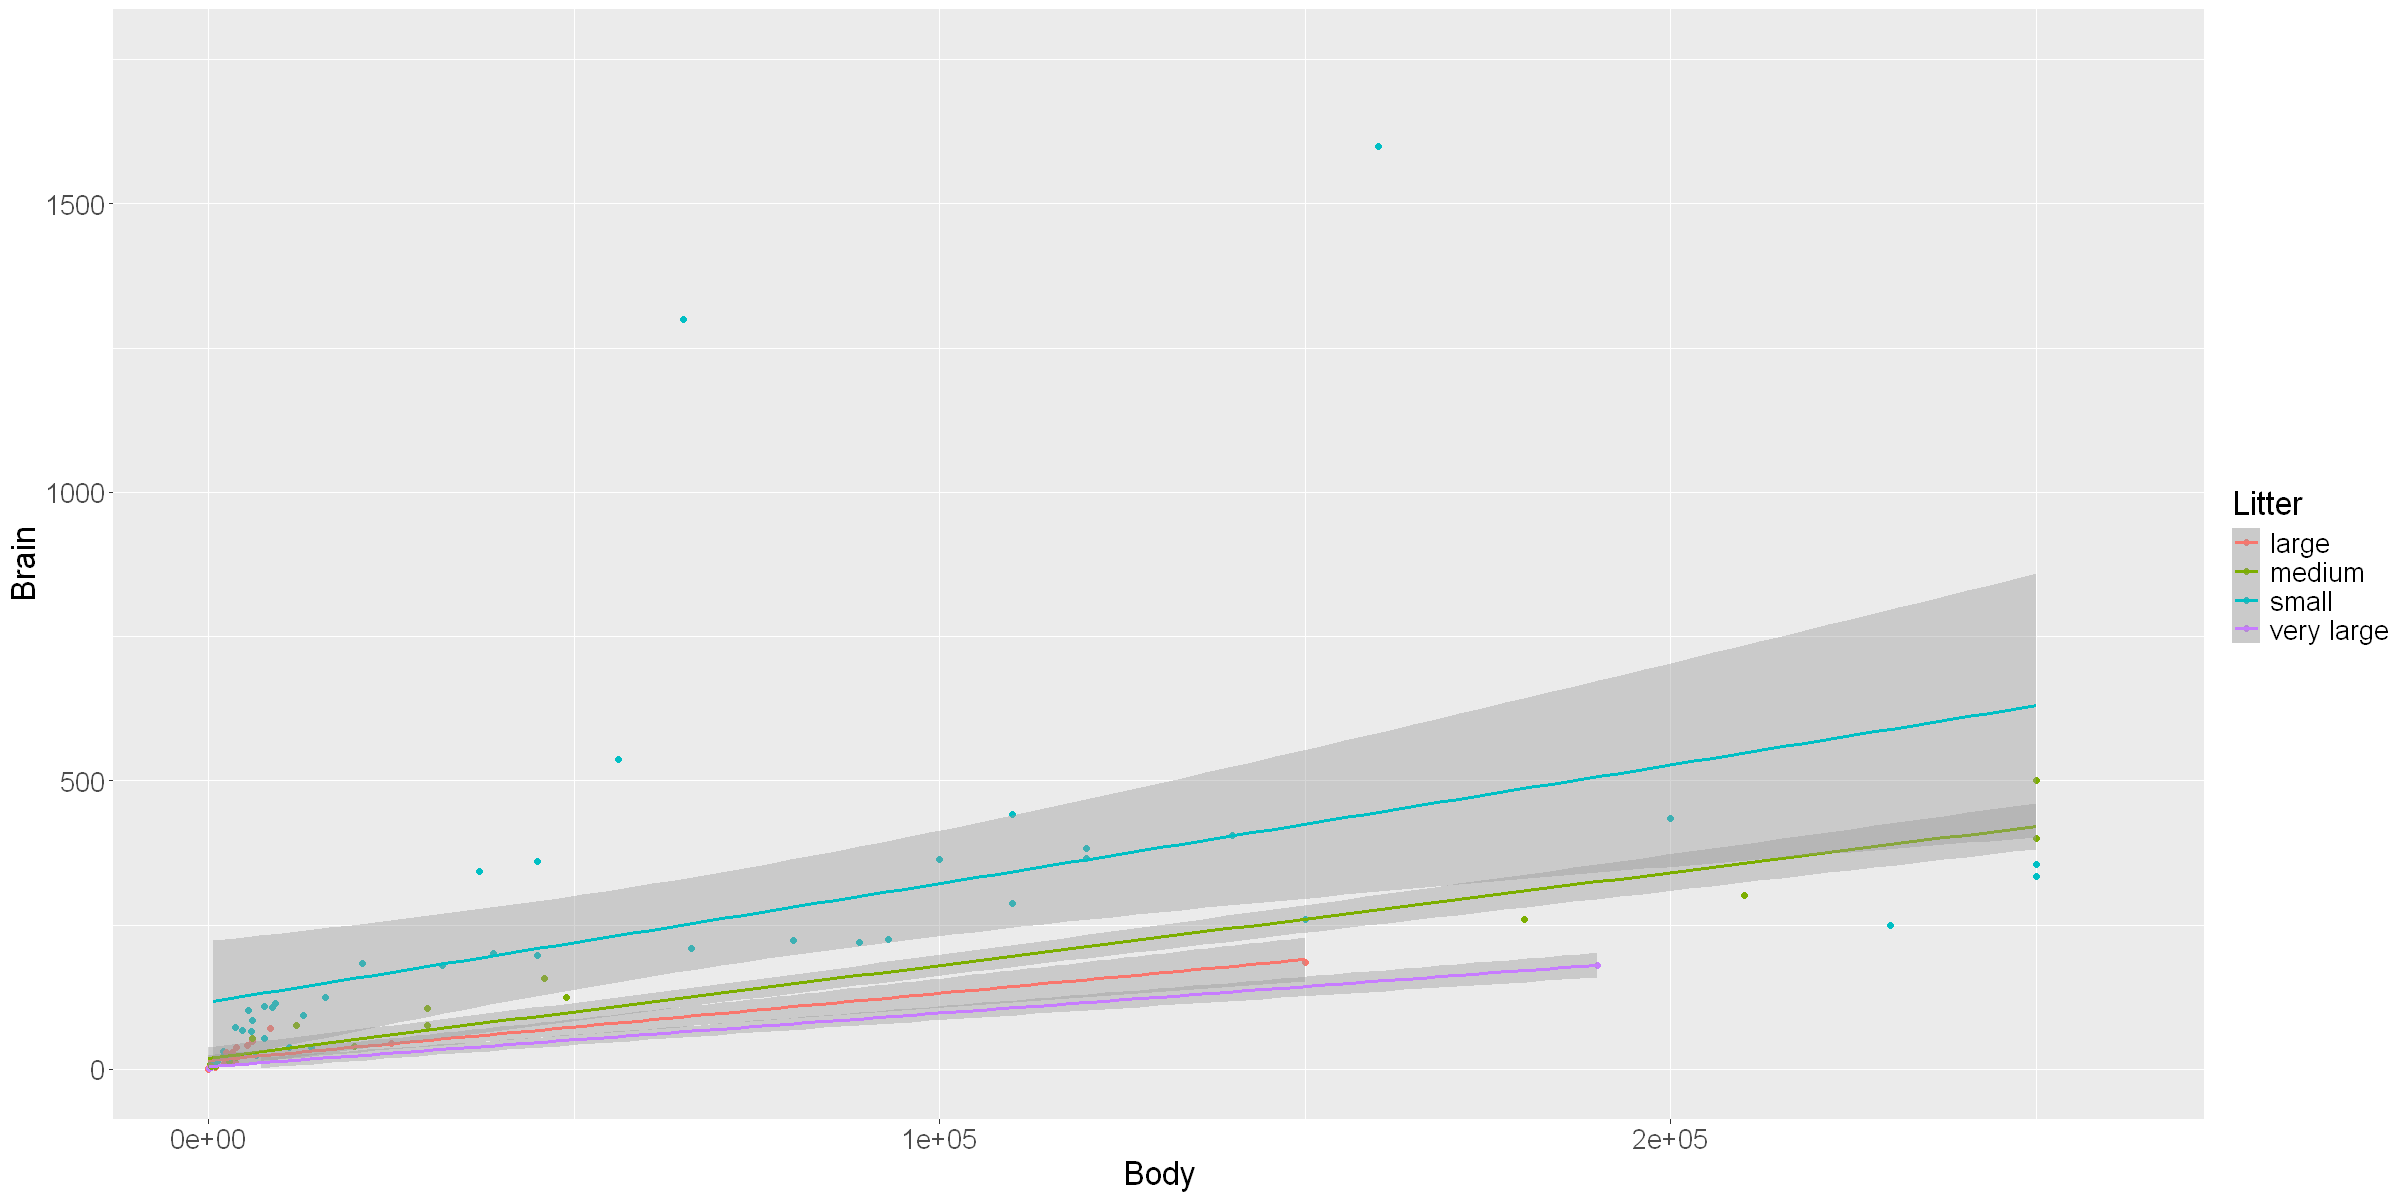

In [19]:
caseBBL = case0902[,c(1,2,3,5)]

ggplot(caseBBL, aes(x=Body, y=Brain, group=Litter, color=Litter)) +
    geom_point() +
    stat_smooth(method="lm", formula = y ~ x) +
    theme(text = element_text(size = 20)) +
    scale_x_continuous(limits = c(0, 260000)) +  # vykreslení je ořezáno
    scale_y_continuous(limits = c(0, 1750))

In [20]:
fitBBL = lm(Brain ~ Body * Litter, data = caseBBL)

tmp = predict(fitBBL, interval="prediction")
caseBBL = cbind(caseBBL, tmp)

head(caseBBL)
summary(fitBBL)

Warning message in predict.lm(fitBBL, interval = "prediction"):
"predictions on current data refer to _future_ responses
"


,Species,Brain,Body,Litter,fit,lwr,upr
,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
1,Quokka,17.50,3500,small,135.15116,-384.6884,654.9908
2,Hedgehog,3.50,930,large,15.92009,-513.6187,545.4589
3,Tree shrew,3.15,150,medium,19.40774,-511.1728,549.9883
4,Elephant shrew I,1.14,49,medium,19.24528,-511.3525,549.8431
5,Elephant shrew II,1.37,64,medium,19.26941,-511.3258,549.8646
6,Lemur,22.00,2100,small,133.34570,-386.5066,653.1980



Call:
lm(formula = Brain ~ Body * Litter, data = caseBBL)

Residuals:
     Min       1Q   Median       3Q      Max 
-1346.10   -53.93   -13.67    16.14  1263.02 

Coefficients:
                        Estimate Std. Error t value Pr(>|t|)
(Intercept)            1.483e+01  6.450e+01   0.230    0.819
Body                   1.168e-03  1.792e-03   0.651    0.516
Littermedium           4.332e+00  9.241e+01   0.047    0.963
Littersmall            1.158e+02  7.539e+01   1.536    0.128
Littervery large      -1.027e+01  1.331e+02  -0.077    0.939
Body:Littermedium      4.409e-04  1.911e-03   0.231    0.818
Body:Littersmall       1.221e-04  1.794e-03   0.068    0.946
Body:Littervery large -2.423e-04  2.337e-03  -0.104    0.918

Residual standard error: 258.7 on 88 degrees of freedom
Multiple R-squared:  0.7589,	Adjusted R-squared:  0.7397 
F-statistic: 39.56 on 7 and 88 DF,  p-value: < 2.2e-16


Vzorec pro odhad váhy mozku podle interakce tělesné hmotnosti a vrhu.

$$
\texttt{Brain} = 
\begin{cases}
\beta_0 + \beta_3 + (\beta_1 + \beta_6) \cdot \texttt{Body} &\text{pokud }\texttt{Litter == small}, \\
\beta_0 + \beta_2 + (\beta_1 + \beta_5) \cdot \texttt{Body} &\text{pokud }\texttt{Litter == medium}, \\
\beta_0 + \beta_1 \cdot \texttt{Body} &\text{pokud }\texttt{Litter == large}, \\
\beta_0 + \beta_4 + (\beta_1 + \beta_7) \cdot \texttt{Body} &\text{pokud }\texttt{Litter == very large}. \\
\end{cases}
$$

S nulovými regresormi je průměrná váha mozku 14.83 g. <br>
U malého vrhu se průměrná váha mozku zvyšuje o 115.80 g a pak ještě o 0.0012901 g na každý gram tělesné hmotnosti. <br>
U středního vrhu se průměrná váha mozku zvyšuje o 4.33 g a pak ještě o 4.3324409 g na každý gram tělesné hmotnosti. <br>
U velkého vrhu se průměrná váha mozku zvyšuje o 0.001168 g každý gram tělesné hmotnosti. <br>
Jenom u velmi velkého vrhu se průměrná váha mozku snižuje o 10.27 g a pak zvyšuje o 0.0009257 na každý gram tělesné hmotnosti.  <br>

Model má zbytková standardní chybu 259 gramu, pokrývá 75.89 % rozptylu Brain a podle p-hodnoty má statistický významný vliv. Ale koeficienty ${\beta}_0$, $Body$, $Litter$ a ani jejich interakce nejsou statistický významné pro odhad váhy mozku. Model proto nebude nejspíše dobře odhadovat vysvětlovanou proměnu.

Warning message:
"Removed 2 rows containing missing values or values outside the scale range (`geom_point()`)."
Warning message:
"Removed 2 rows containing missing values or values outside the scale range (`geom_line()`)."


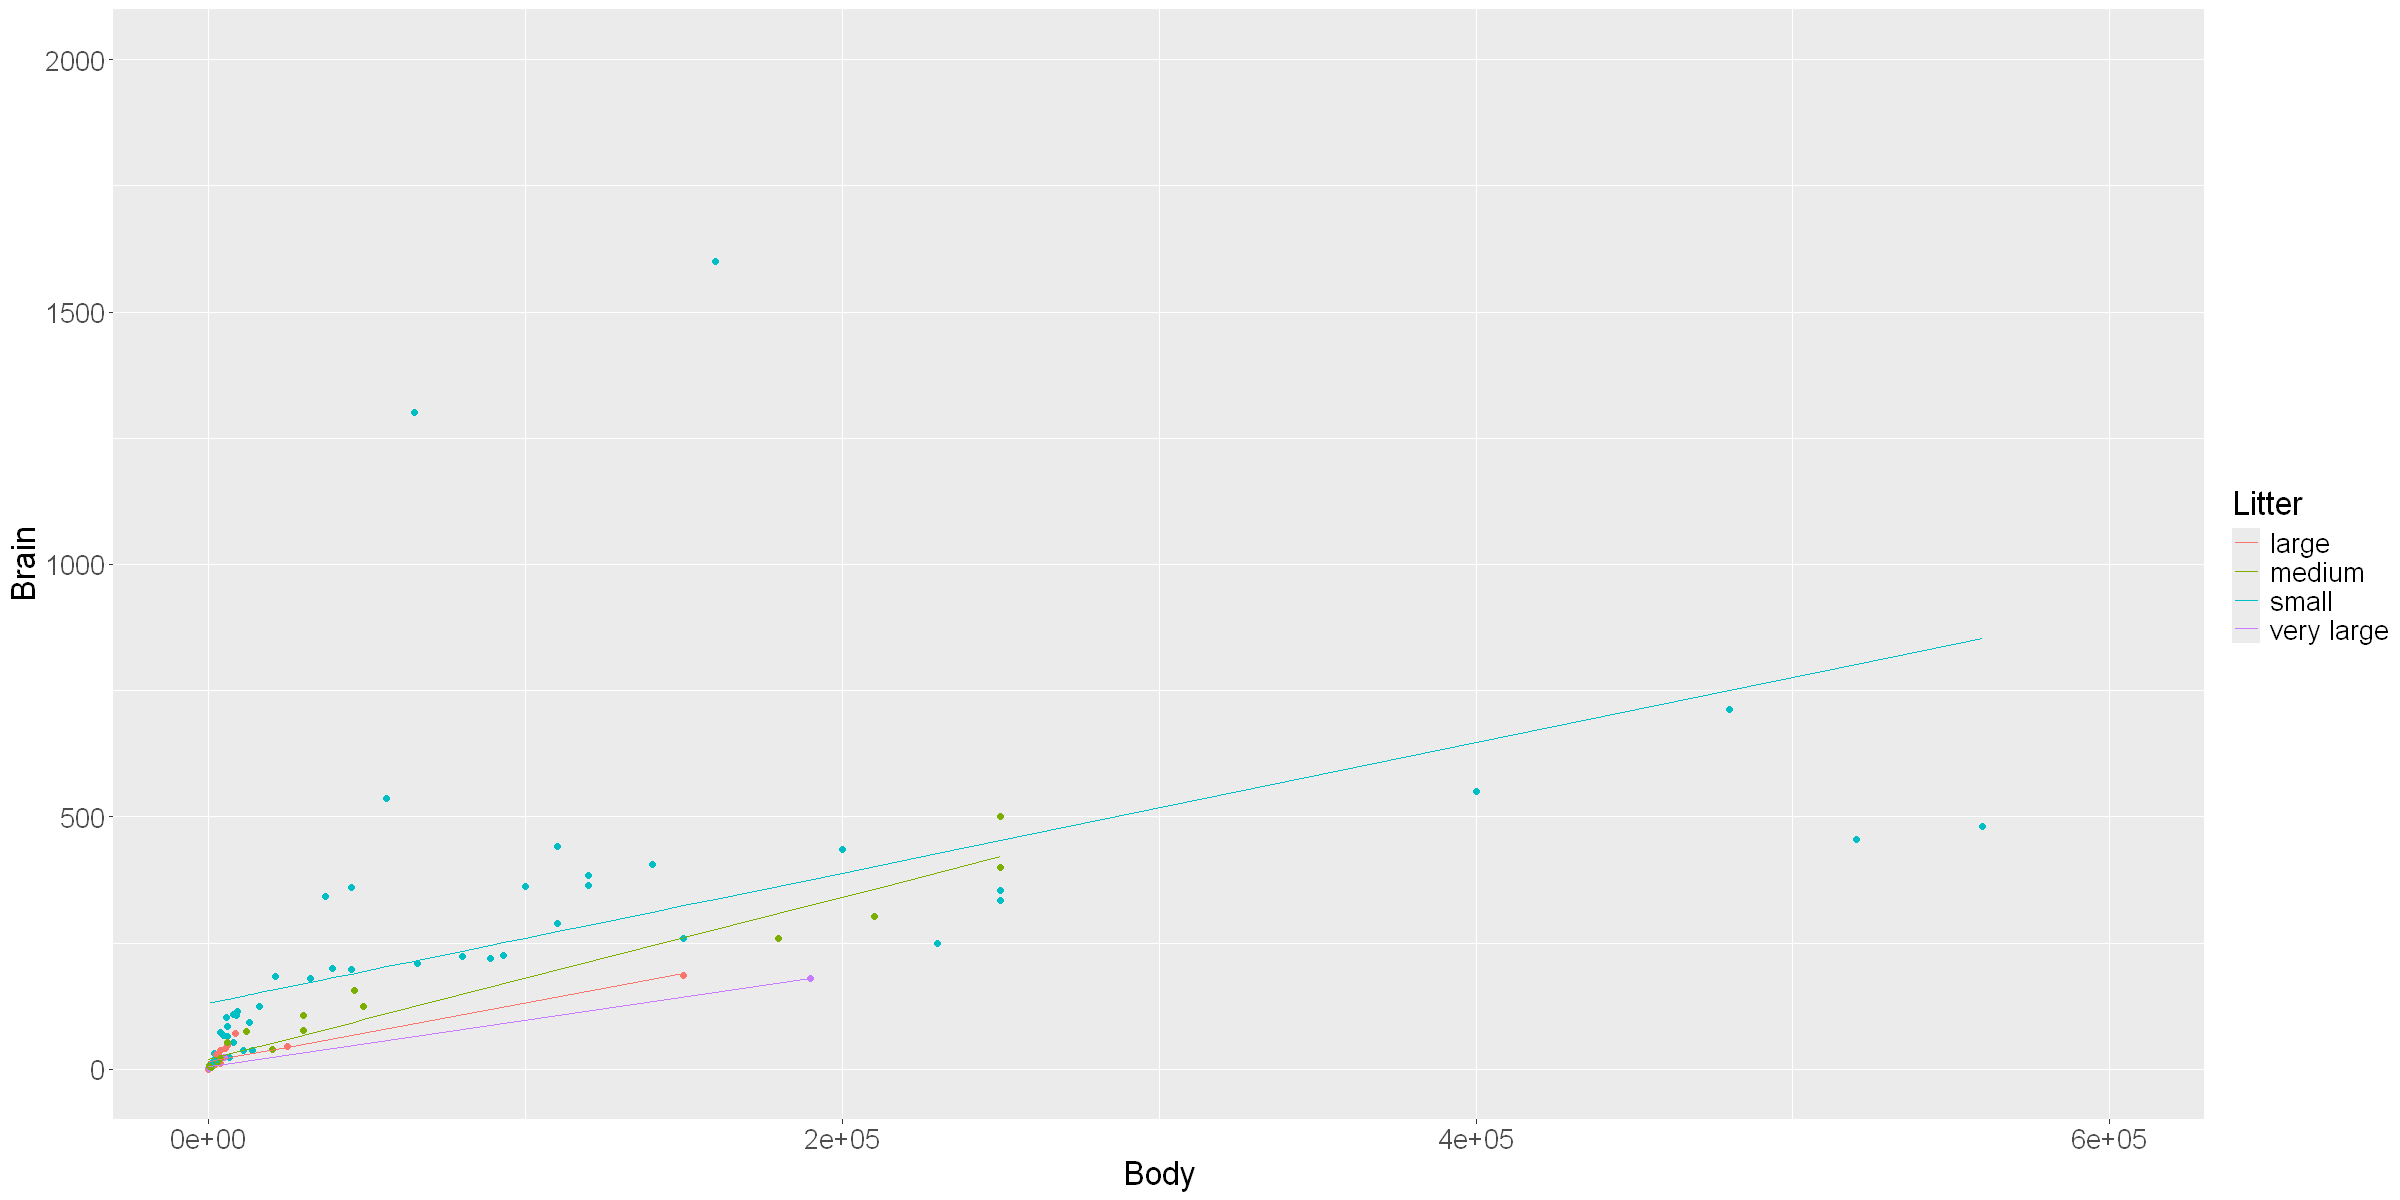

In [21]:
ggplot(caseBBL, aes(x=Body, y=Brain, group=Litter, color=Litter)) +
    geom_point(show.legend=F) +
    geom_line(aes(y=fit)) +
    theme(text = element_text(size = 20)) +
    scale_x_continuous(limits = c(0, 600000)) +
    scale_y_continuous(limits = c(0, 2000))

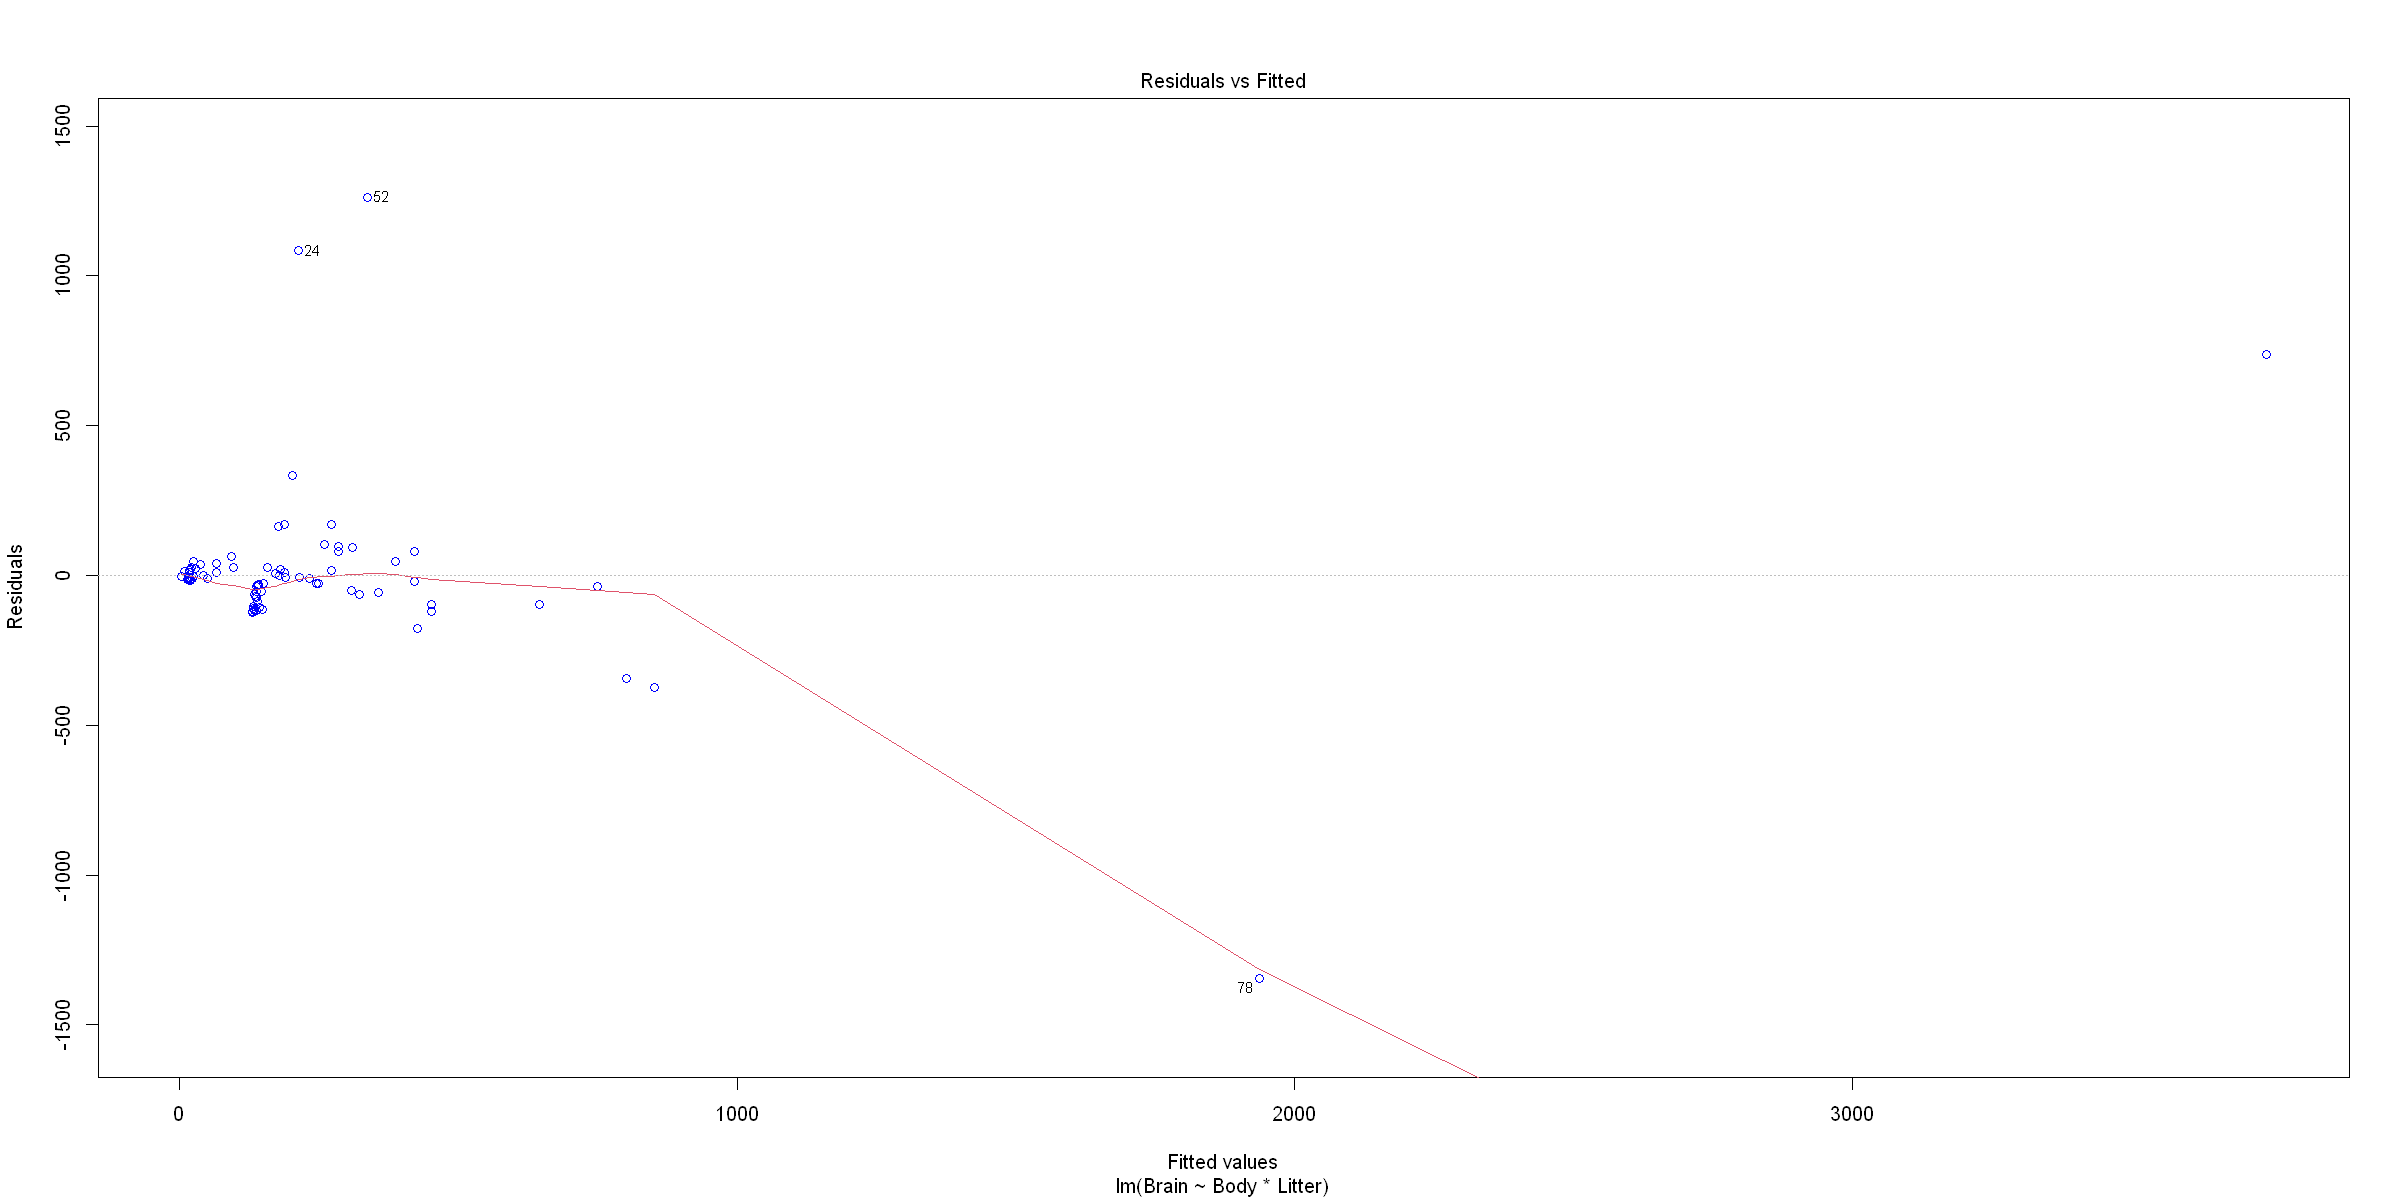

In [22]:
plot(fitBBL, which=1, col=c("blue"))

Pro nízké hodnoty model funguje správně ale s rostoucí hodnotami pak rychle slábne.

## Tri regresory
Na poslední model použiji všechny proměnné jako regresory, hmotnost, březost a vrh. <br>

Nejdříve si vytvořím plný model a model s interakcemi. Pak si je porovnám a budu redukovat nepotřebné regresory.

In [23]:
caseBBGL = case0902[,c(1,2,3,4,5)]

fitBBGL_full = lm(Brain ~ Body + Gestation + Litter, data = caseBBGL)
summary(fitBBGL_full)

fitBBGL_int = lm(Brain ~ Body * Gestation * Litter, data = caseBBGL)
summary(fitBBGL_int)


Call:
lm(formula = Brain ~ Body + Gestation + Litter, data = caseBBGL)

Residuals:
     Min       1Q   Median       3Q      Max 
-1009.70   -58.42    23.76    56.62   982.99 

Coefficients:
                   Estimate Std. Error t value Pr(>|t|)    
(Intercept)      -8.423e+01  5.670e+01  -1.486   0.1409    
Body              9.769e-04  9.554e-05  10.225  < 2e-16 ***
Gestation         1.905e+00  3.771e-01   5.053 2.27e-06 ***
Littermedium     -6.737e+01  7.482e+01  -0.900   0.3703    
Littersmall      -1.410e+02  8.113e+01  -1.738   0.0856 .  
Littervery large -1.896e+01  1.066e+02  -0.178   0.8592    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 226.1 on 90 degrees of freedom
Multiple R-squared:  0.8115,	Adjusted R-squared:  0.801 
F-statistic:  77.5 on 5 and 90 DF,  p-value: < 2.2e-16



Call:
lm(formula = Brain ~ Body * Gestation * Litter, data = caseBBGL)

Residuals:
    Min      1Q  Median      3Q     Max 
-508.19  -20.20   -1.16    8.96  955.15 

Coefficients:
                                  Estimate Std. Error t value Pr(>|t|)  
(Intercept)                     -6.185e+00  8.270e+01  -0.075   0.9406  
Body                             1.186e-02  3.049e-02   0.389   0.6983  
Gestation                        2.401e-01  1.403e+00   0.171   0.8646  
Littermedium                     1.827e+01  1.201e+02   0.152   0.8795  
Littersmall                     -1.912e+02  1.089e+02  -1.756   0.0829 .
Littervery large                 2.728e+00  3.361e+02   0.008   0.9935  
Body:Gestation                  -8.972e-05  2.521e-04  -0.356   0.7229  
Body:Littermedium               -1.074e-02  3.052e-02  -0.352   0.7259  
Body:Littersmall                -1.224e-02  3.049e-02  -0.401   0.6893  
Body:Littervery large           -6.932e-03  9.866e-01  -0.007   0.9944  
Gestation:Litter

Porovnáním statistik, model s interakcemi se zdá být lepším. Budu dál s ním pracovat a zkoušet ho redukovat.

In [24]:
step(lm(Brain ~ 1, data=caseBBGL),scope=list(lower=~1,upper=~Body*Gestation*Litter))

Start:  AIC=1196.86
Brain ~ 1

            Df Sum of Sq      RSS    AIC
+ Body       1  18228007  6188566 1067.1
+ Gestation  1  12947201 11469373 1126.3
+ Litter     3   2093210 22323364 1194.2
<none>                   24416574 1196.9

Step:  AIC=1067.09
Brain ~ Body

            Df Sum of Sq      RSS    AIC
+ Gestation  1   1422101  4766465 1044.0
<none>                    6188566 1067.1
+ Litter     3    280956  5907610 1068.6
- Body       1  18228007 24416574 1196.9

Step:  AIC=1044.03
Brain ~ Body + Gestation

                 Df Sum of Sq      RSS     AIC
+ Body:Gestation  1   1966695  2799770  994.95
<none>                         4766465 1044.03
+ Litter          3    164455  4602011 1046.65
- Gestation       1   1422101  6188566 1067.09
- Body            1   6702908 11469373 1126.32

Step:  AIC=994.95
Brain ~ Body + Gestation + Body:Gestation

                 Df Sum of Sq     RSS     AIC
<none>                        2799770  994.95
+ Litter          3     44046 2755724  999.


Call:
lm(formula = Brain ~ Body + Gestation + Body:Gestation, data = caseBBGL)

Coefficients:
   (Intercept)            Body       Gestation  Body:Gestation  
    -7.506e+01      -2.479e-04       1.536e+00       2.308e-06  


In [25]:
fitBBGL_reduced = lm(Brain ~ Body * Gestation, data = caseBBGL)
summary(fitBBGL_reduced)


Call:
lm(formula = Brain ~ Body * Gestation, data = caseBBGL)

Residuals:
    Min      1Q  Median      3Q     Max 
-423.85  -73.00   -9.17   40.83 1028.95 

Coefficients:
                 Estimate Std. Error t value Pr(>|t|)    
(Intercept)    -7.506e+01  3.350e+01  -2.241   0.0275 *  
Body           -2.479e-04  1.738e-04  -1.426   0.1572    
Gestation       1.536e+00  2.124e-01   7.231 1.38e-10 ***
Body:Gestation  2.308e-06  2.871e-07   8.039 2.99e-12 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 174.4 on 92 degrees of freedom
Multiple R-squared:  0.8853,	Adjusted R-squared:  0.8816 
F-statistic: 236.8 on 3 and 92 DF,  p-value: < 2.2e-16


Body nemá statisticky významný vliv na odhad Brain, zkusím ho taky dát pryč.

In [26]:
fitBBGL_final = lm(Brain ~ Gestation + Body:Gestation, data = caseBBGL)
summary(fitBBGL_final)


Call:
lm(formula = Brain ~ Gestation + Body:Gestation, data = caseBBGL)

Residuals:
    Min      1Q  Median      3Q     Max 
-413.38  -72.32    0.72   42.27 1042.05 

Coefficients:
                 Estimate Std. Error t value Pr(>|t|)    
(Intercept)    -7.396e+01  3.368e+01  -2.196   0.0306 *  
Gestation       1.446e+00  2.040e-01   7.089 2.58e-10 ***
Gestation:Body  1.933e-06  1.156e-07  16.725  < 2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 175.4 on 93 degrees of freedom
Multiple R-squared:  0.8828,	Adjusted R-squared:  0.8803 
F-statistic: 350.3 on 2 and 93 DF,  p-value: < 2.2e-16


Teď už jsou všechny proměnné statisticky významné a jdu si model interpretovat.

In [27]:
fitBBGL = fitBBGL_final
tmp = predict(fitBBGL, interval="prediction")
caseBBGL = cbind(caseBBGL, tmp)
head(caseBBGL)
summary(fitBBGL)

Warning message in predict.lm(fitBBGL, interval = "prediction"):
"predictions on current data refer to _future_ responses
"


,Species,Brain,Body,Gestation,Litter,fit,lwr,upr
,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
1,Quokka,17.50,3500,26,small,-36.1841204,-389.3724,317.0041
2,Hedgehog,3.50,930,34,large,-24.7304371,-377.5136,328.0527
3,Tree shrew,3.15,150,46,medium,-7.4255356,-359.6571,344.8060
4,Elephant shrew I,1.14,49,51,medium,-0.2037583,-352.2251,351.8176
5,Elephant shrew II,1.37,64,46,medium,-7.4331818,-359.6647,344.7983
6,Lemur,22.00,2100,135,small,121.8081291,-228.4183,472.0345



Call:
lm(formula = Brain ~ Gestation + Body:Gestation, data = caseBBGL)

Residuals:
    Min      1Q  Median      3Q     Max 
-413.38  -72.32    0.72   42.27 1042.05 

Coefficients:
                 Estimate Std. Error t value Pr(>|t|)    
(Intercept)    -7.396e+01  3.368e+01  -2.196   0.0306 *  
Gestation       1.446e+00  2.040e-01   7.089 2.58e-10 ***
Gestation:Body  1.933e-06  1.156e-07  16.725  < 2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 175.4 on 93 degrees of freedom
Multiple R-squared:  0.8828,	Adjusted R-squared:  0.8803 
F-statistic: 350.3 on 2 and 93 DF,  p-value: < 2.2e-16


Vzorec pro odhad váhy mozku podle Gestation a interakce Gestation a Body:
$$ Brain = -73.96 + 1.446 \cdot Gestation + 1.933e^{-6} \cdot Gestaion \cdot Body $$
S nulovými regresormi je průměrná váha mozku -73.96 g, co nemůže nastat. <br>
Váha mozku se zvyšuje o 1.664 g s každým dnem březosti. <br>
Taky se zvyšuje o 1.933e$^{-6}$ g s interakci mezi délkou březosti a tělesní vahou. <br>

Všechny koeficienty (${\beta}_0$, $Gestation$, $Gestation:Body$) mají statisticky významný vliv na proměnou Brain. Zbytková standardní chyba je 175. Model vysvětluje přibližně 88.28 % rozptylu Brain. Hodnoty Multiple $R^2$ a Adjusted $R^2$ jsou si podobné co taky poukazuje na dobrou kvalitu modelu. F-statistika s p-hodnotou mi ukazuje, že model je statisticky významný.


In [28]:
# prechod od záporných hodnot na kladné 
caseBBGL_ord = caseBBGL[order(caseBBGL$Gestation, decreasing = FALSE), ]
caseBBGL_ord[c(19,20,21,22),]

,Species,Brain,Body,Gestation,Litter,fit,lwr,upr
,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
5,Elephant shrew II,1.37,64,46,medium,-7.4331818,-359.6647,344.7983
4,Elephant shrew I,1.14,49,51,medium,-0.2037583,-352.2251,351.8176
55,Red fox,48.00,6000,52,large,1.8405063,-350.1431,353.8241
62,Badger,53.00,6000,60,medium,13.5017351,-338.1733,365.1768


Model se jeví jako nejlepší, ale trochu mi na něm vadí záporný odhady, 20 z 96. Model odhaduje záporné váhy u krátké doby březnosti, nad 52 dnu jsou odhady už kladné. 

## Předpoklady metod

Nejdřív si zkontroluji, jestli přidáním interakci se mi zlepšil model.

In [29]:
anova(fitBBGL_full,fitBBGL_int,test="F")

,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,90,4602011,NA,NA,NA,NA
2,80,2429026,10,2172985,7.156728,5.985367e-08


Mezi modely jsou statistické rozdílí, tudíž interakce jsou statisticky významné.

Tese ď ale musíe taky musím podívat, jestli odebráním regresoru se mi model nezhoršil. 

In [30]:
anova(fitBBGL_int, fitBBGL_reduced,test="F")
anova(fitBBGL_reduced, fitBBGL_final,test="F")

,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,80,2429026,NA,NA,NA,NA
2,92,2799770,-12,-370744.6,1.01754,0.4412052


,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,92,2799770,NA,NA,NA,NA
2,93,2861670,-1,-61899.33,2.034002,0.1571997


Testy mi říkají, že mezi modely není statistický významný rozdíl a proto můžu použit finální redukovaný model.

Při redukci se mi taky snížil rozsah popisu ale mohla se snížit i komplexnost, podívám se proto na informační kritéria abych našel nejlepší model.

In [31]:
fitbb_AIC = AIC(fitBBGL_full, fitBBGL_int, fitBBGL_reduced, fitBBGL_final)
fitbb_BIC = BIC(fitBBGL_full, fitBBGL_int, fitBBGL_reduced, fitBBGL_final)
fitbb_BIC$df = NULL
cbind( fitbb_AIC, fitbb_BIC )

,df,AIC,BIC
,<dbl>,<dbl>,<dbl>
fitBBGL_full,7,1321.091,1339.042
fitBBGL_int,17,1279.747,1323.341
fitBBGL_reduced,5,1269.383,1282.205
fitBBGL_final,4,1269.483,1279.740


Podle obou kritérií je finalní model nejšikovnější.

Abych mohl výsledky regresní analýzy smysluplně interpretovat, musí být splněny určité podmínky.

-----------------------------------------------
       Test             Statistic       pvalue  
-----------------------------------------------
Shapiro-Wilk              0.6162         0.0000 
Kolmogorov-Smirnov        0.2667         0.0000 
Cramer-von Mises          7.9119         0.0000 
Anderson-Darling          8.5879         0.0000 
-----------------------------------------------

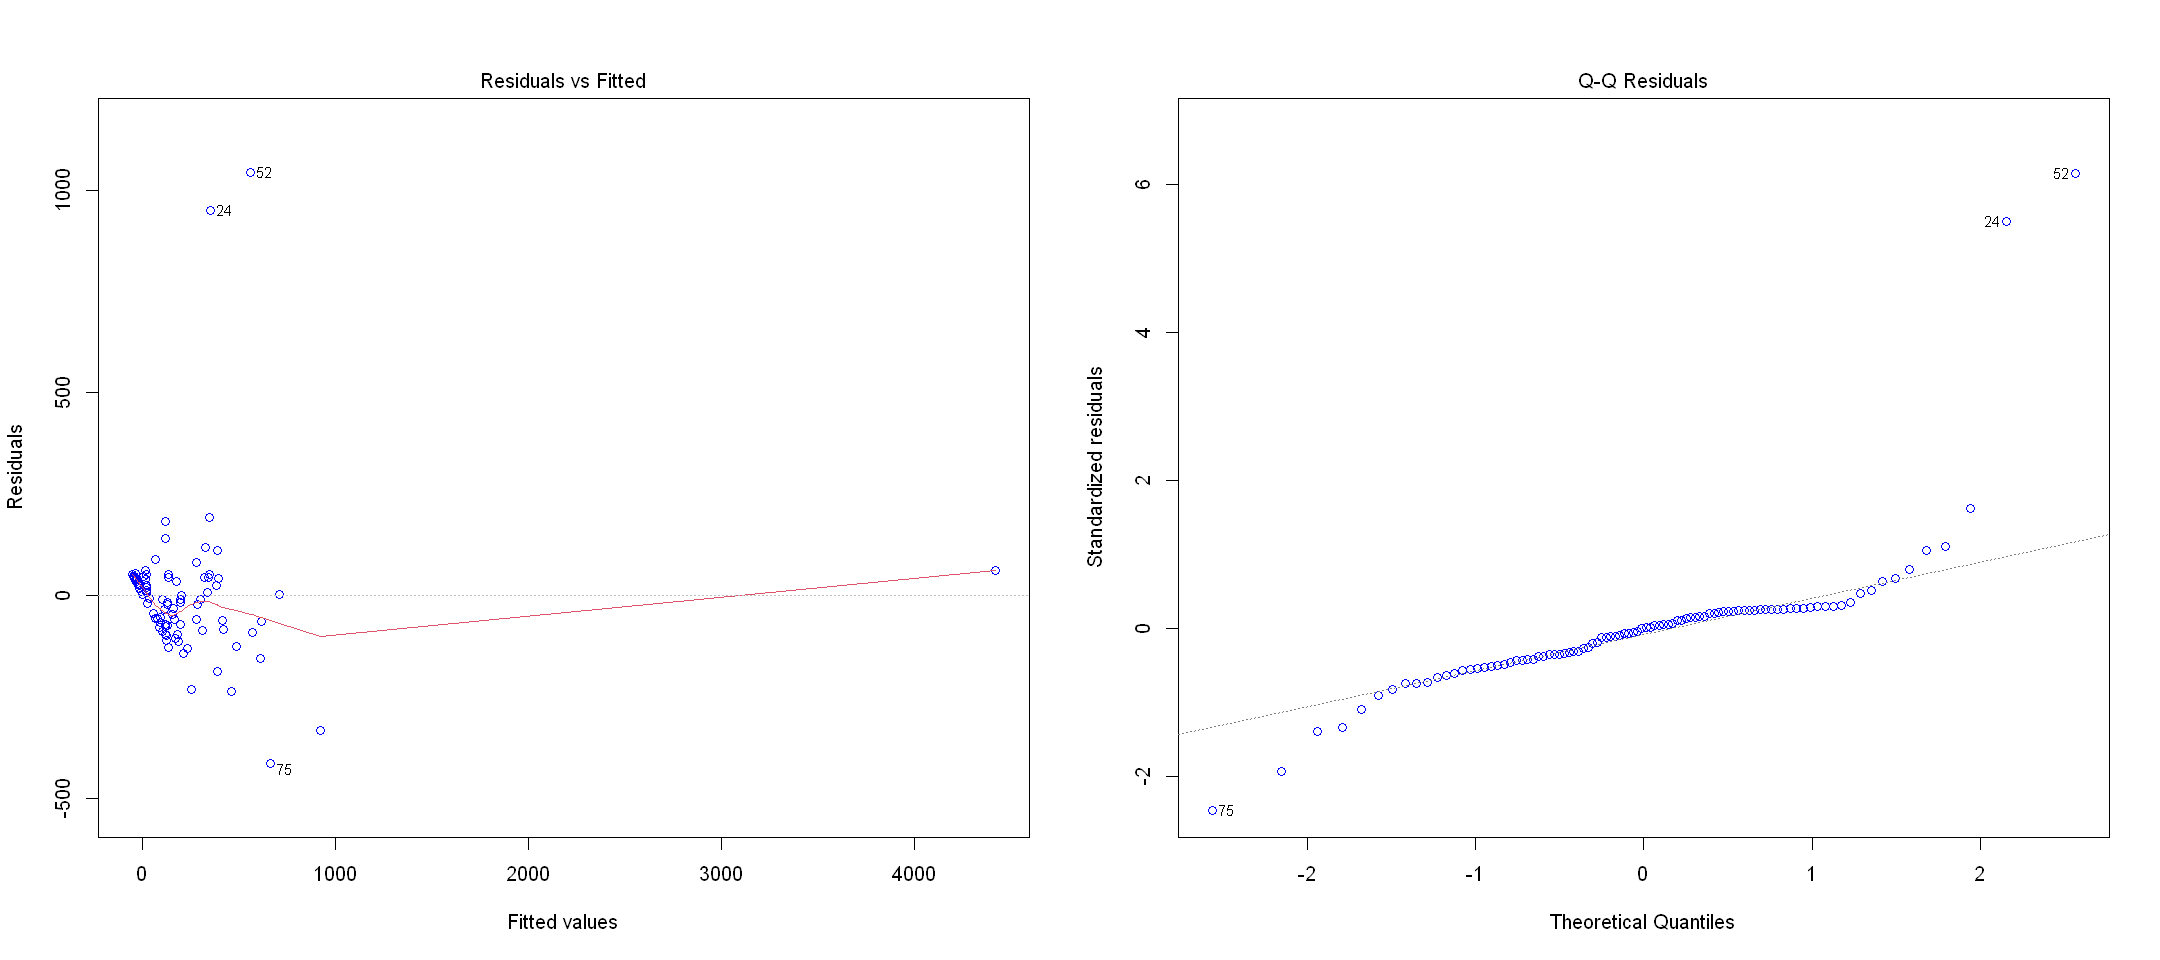

In [32]:
options(repr.plot.width = 18, repr.plot.height = 8)

par(mfrow=c(1,2))
plot(fitBBGL, which=1, col=c("blue"))
plot(fitBBGL, which=2, col=c("blue"))

ols_test_normality(fitBBGL)

Rezidua sledují vzor, model tudiž nesplňuje linearitu. <br>
U normality, všechny testy mají p-hodnotu < 0.05 a tudíž se zamítá hypotéza normálního rozdělení.<br>

In [33]:
dwtest(fitBBGL)


	Durbin-Watson test

data:  fitBBGL
DW = 1.8159, p-value = 0.196
alternative hypothesis: true autocorrelation is greater than 0


Podle Durbin-Watsonove p-hodnoty > 0.05, nezamítám nulovou hypotézu existence autokorelace.<br>


 Breusch Pagan Test for Heteroskedasticity
 -----------------------------------------
 Ho: the variance is constant            
 Ha: the variance is not constant        

              Data                
 ---------------------------------
 Response : Brain 
 Variables: fitted values of Brain 

         Test Summary           
 -------------------------------
 DF            =    1 
 Chi2          =    12.07828 
 Prob > Chi2   =    0.0005101252 

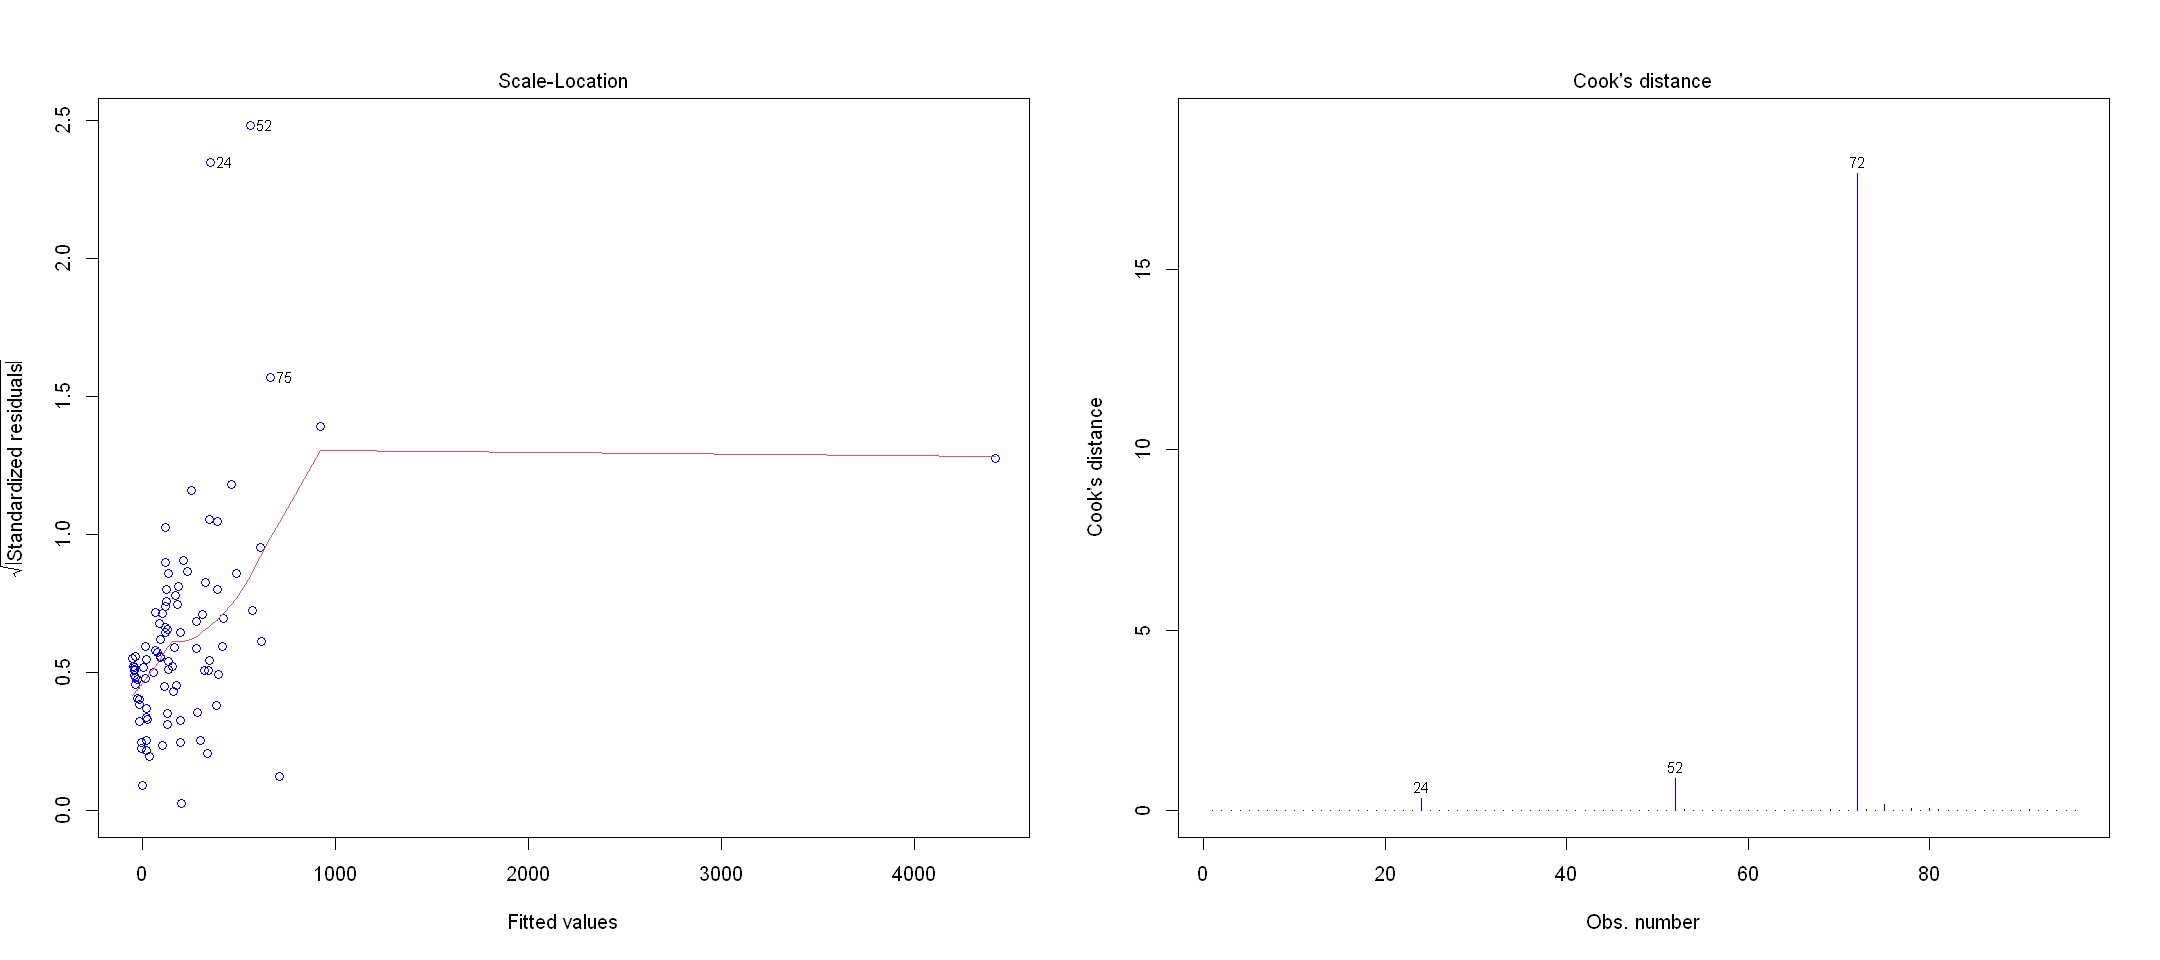

In [34]:
par(mfrow=c(1,2))
plot(fitBBGL, which=3, col=c("blue"))
plot(fitBBGL, which=4, col=c("blue"))

ols_test_breusch_pagan(fitBBGL)

In [35]:
caseBBGL[c(24,52,72),]

,Species,Brain,Body,Gestation,Litter,fit,lwr,upr
,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
24,Human being,1300,65000,270,small,350.3987,-3.447577,704.2450
52,Dolphin,1600,160000,360,small,557.9530,198.309114,917.5969
72,African elephant,4480,2800000,655,small,4417.9901,3931.234059,4904.7462


U homoskedasticity, je p-hodnota nižší než hladina významnosti, zamítám nulovou hypotézu a přikláním se k alternativě že v reziduích existuje heteroskedasticita. <br>
U Cookové vzdálenosti vidím jednu hodnotu, která má velmi velký vliv na odhady. Jedná se afrického slona, kterého jsme našli i u prvotní analýzy a teď působí problémy. <br>
Většina testu nedopadla dobře. Model by potřeboval lépe optimalizovat a vypořádat se s outlierami.